In [1]:
!pip install ~/fwiVis/utility_functions/
! pip install plotnine

Processing /home/jovyan/fwiVis/utility_functions
  Preparing metadata (setup.py) ... done
  Created wheel for fwiVis: filename=fwiVis-0.1-py3-none-any.whl size=17985 sha256=1a3d72e6ab641f0f463af6fe1997e499897eb29fcc8b4fa668bd5ee59ac7e573
  Stored in directory: /tmp/pip-ephem-wheel-cache-9pslo5iu/wheels/79/0f/3d/08c18473dd7e0fb915900e6b4f13b81f1fa84371f9bf24d864
Successfully built fwiVis
  Attempting uninstall: fwiVis
    Found existing installation: fwiVis 0.1
    Uninstalling fwiVis-0.1:
      Successfully uninstalled fwiVis-0.1


In [2]:
import s3fs
s3 = s3fs.S3FileSystem(anon=False)
from math import cos, asin, sqrt
import re

import numpy as np
import geopandas as gpd
import pandas as pd
from matplotlib import pyplot as plt
import os
import rioxarray as rio
import xarray as xr
import rasterio
import glob
from shapely.errors import ShapelyDeprecationWarning
from shapely.geometry import Point
import warnings
import folium
import datetime
import time
from folium import plugins
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning) 
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning) 
#import contextily as cx
from shapely.geometry import box
import sys
from datetime import datetime, timedelta
from itertools import chain

from datetime import date
from bs4 import BeautifulSoup
import requests
import os
import plotnine
import xarray as xr

#import numpy as np
from matplotlib import pyplot as plt
from plotnine import ggplot, geom_point, geom_jitter, aes, stat_smooth, facet_wrap
import plotnine as plotnine
import seaborn as sns

from scipy import stats
from patsy import ModelDesc
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

import math
import pickle

In [3]:
import fwiVis.fwiVis as fv

#path = "/projects/old_shared/fire_weather_vis/Lightning_analysis/fwi_timeline_only/April_1_unmerged_fires_with_FWI.csv"
#path = "/projects/old_shared/fire_weather_vis/Lightning_analysis/fwi_timeline_merge/Final_dataset_as_of_20240209.csv"
#fire3 = fv.prep_fire_files(path)

path = os.path.abspath("data/Quebec_v3_full_data_perimeters20241112.csv")
#path = os.path.abspath("data/Quebec_v3_full_data_perimetersMAX_fwi_with_ISI_and_BUIful_timeseries_202534.csv")
fire3 = fv.prep_fire_files(path)
fire_first = fire3


ciffc = pd.read_csv(os.path.abspath("contextual_data/CIFFC_data/ciffc_all_canada.csv"))
ciffc = ciffc[ciffc.field_agency_code == "qc"]

ciffc = gpd.GeoDataFrame(ciffc, geometry= gpd.points_from_xy(ciffc.field_longitude, ciffc.field_latitude), crs = "4326")
ciffc = ciffc.to_crs("3571")

ciffc["geometry_point"] = ciffc.geometry

In [4]:
fire3 = fire3.sort_values(by = ["fireID", "t"])

fire3 = fire3[~fire3.FWI.isna()]
# df = fire3[fire3.fireID == '2367']
# df

In [5]:
def corrected_farea_diff(df, var = "farea"):
    #sub_df = df[]
    df = df.drop_duplicates()
    df[f"{var}_diff"] = df[var].diff()
    min_t = df.t.min()
    #print()
    #print(df.loc[df.t == min_t, ["fireID", "t", "farea", "farea_diff"]])
    
    if(np.isnan(*df.loc[df.t == min_t, [f"{var}_diff"]].values)):
        df.loc[df.t == min_t, [f"{var}_diff"]] = df.loc[df.t == min_t, [f"{var}"]].values
    else:
        print("Error! First value not NaN")
        df = None
    return(df)

In [6]:
def just_the_igs(df,): ## Reminder that this will only acocunt for the earliest ignition from a multi-fire complex. 

    df["is_ig"] = False
    df.loc[df.t == df.t.min(), ['is_ig']] = True
    
    return(df)

def extinction(df, days_past = 1):
    df.loc[:, ['is_ext']] = False
    df.loc[:, ["t"]] = df.t.astype("datetime64[ns]")
    final_t = df[df.n_newpixels > 0].t.astype("datetime64[ns]").max()
    post_fire = final_t + timedelta(days = days_past)

    if (pd.isnull(np.datetime64(str(final_t)))):
        df.loc[(df.t == df.t.min()), ['is_ext']] = True
    else:
        df.loc[(df.t  > final_t)  & (df.t  <= post_fire), ['is_ext']] = True
    #print(final_t)
    #print(df.fireID.unique())
    #print(len(df[df["is_ext"] == True]))
    return(df)


#fire3 = fire3[~fire3.FWI.isna()]

In [7]:
def chop_fires_at_end(df):
    final_t = df[df.n_newpixels > 0].t.max()
    df = df[df.t <= final_t]
    return(df)

#post_fr = fire3.groupby("fireID").apply(extinction).reset_index(drop = True)
fire3 = fire3.groupby("fireID").apply(chop_fires_at_end).reset_index(drop = True)


fire3 = fire3.sort_values(by = ["fireID", "t"])

/tmp/ipykernel_2413/3123191034.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


In [8]:
### make a plot of the distribution of forwar-facing relative fire area growth
fire3 = fire3.drop_duplicates()
fire3["farea_diff_stand"] = fire3.groupby("fireID").farea.diff()

fire3["corrected_flinelen"] = fire3.flinelen + 0.001

## Fireline 
fire3["frac_change"] = fire3.groupby("fireID").farea.pct_change()
fire3["flinelen_frac_change"] = fire3.groupby("fireID").corrected_flinelen.pct_change()

fire3["fperim_shifted"] = fire3.groupby("fireID").fperim.shift(periods = 1)
fire3["flinelen_diff"] = fire3.groupby("fireID").flinelen.diff()
fire3["fperim_diff"] = fire3.groupby("fireID").fperim.diff()


fire3["farea_shifted"] = fire3.groupby("fireID").farea.shift(periods = 1)
fire3["meanFRP_shifted"] = fire3.groupby("fireID").meanFRP.shift(periods = 1)
fire3["flinelen_shifted"] = fire3.groupby("fireID").flinelen.shift(periods = 1)
fire3["n_newpixels_shifted"] = fire3.groupby("fireID").n_newpixels.shift(periods = 1)
fire3["GEOS5_IMERGEARLY_shifted"] = fire3.groupby("fireID")['GEOS-5.IMERGEARLY'].shift(periods = 1)
fire3["FWI_shifted"] = fire3.groupby("fireID")['FWI'].shift(periods = 1)
fire3["FWI_lead_1_shifted"] = fire3.groupby("fireID")['FWI_lead_1'].shift(periods = 1)
fire3["FWI_forecast_average"] = (fire3.FWI + fire3.FWI_lead_1)/2
fire3["FWI_forecast_average_shifted"] = (fire3.FWI_shifted + fire3.FWI_lead_1_shifted)/2
# fire3["ISI_shifted"] = fire3.groupby("fireID")['ISI'].shift(periods = 1)
# fire3["ISI_lead_1_shifted"] = fire3.groupby("fireID")['ISI_lead_1'].shift(periods = 1)
# fire3["ISI_forecast_average"] = (fire3.ISI + fire3.ISI_lead_1)/2
# fire3["ISI_forecast_average_shifted"] = (fire3.ISI_shifted + fire3.ISI_lead_1_shifted)/2
# fire3["BUI_shifted"] = fire3.groupby("fireID")['BUI'].shift(periods = 1)
# fire3["BUI_lead_1_shifted"] = fire3.groupby("fireID")['BUI_lead_1'].shift(periods = 1)
# fire3["BUI_forecast_average"] = (fire3.BUI + fire3.BUI_lead_1)/2
# fire3["BUI_forecast_average_shifted"] = (fire3.BUI_shifted + fire3.BUI_lead_1_shifted)/2




fire3["corrected_shifted_flinelen"] = fire3.flinelen_shifted + 0.001
fire3["flinelen_shifted_frac_change"] = fire3.groupby("fireID").corrected_shifted_flinelen.pct_change()

fire3["farea_shifted_exp"] = fire3["farea_shifted"] ** (1/10)
fire3["meanFRP_shifted_exp"] = fire3["meanFRP_shifted"]** (1/10)
fire3["flinelen_shifted_exp"] = fire3["flinelen_shifted"]** (1/10)
fire3["n_newpixels_shifted_exp"] = fire3["n_newpixels_shifted"]** (1/10)


fire3["spread_bool"] = fire3.frac_change > 0
fire3["spread_bool"] = fire3["spread_bool"].astype("int")


fire3["spread_bool_50"] = fire3.frac_change > 0.5
fire3["spread_bool_50"] = fire3["spread_bool_50"].astype("int")

fire3["spread_bool_frac_01"] = fire3.frac_change > 0.1
fire3["spread_bool_frac_01"] = fire3["spread_bool_frac_01"].astype("int")

fire3["spread_bool_frac_05"] = fire3.frac_change > 0.05
fire3["spread_bool_frac_05"] = fire3["spread_bool_frac_05"].astype("int")

fire3["spread_bool_frac_025"] = fire3.frac_change > 0.025
fire3["spread_bool_frac_025"] = fire3["spread_bool_frac_025"].astype("int")



fire3["spread_bool_100"] = fire3.farea_diff_stand > 1
fire3["spread_bool_100"] = fire3["spread_bool_100"].astype("int")

fire3.loc[:, "spread_bool_200"] = fire3.farea_diff_stand > 2
fire3.loc[:, "spread_bool_200"] = fire3["spread_bool_200"].astype("float")

fire3.loc[:, "spread_bool_400"] = fire3.farea_diff_stand > 4
fire3.loc[:, "spread_bool_400"] = fire3["spread_bool_400"].astype("float")

fire3.loc[:, "spread_bool_600"] = fire3.farea_diff_stand > 6
fire3.loc[:, "spread_bool_600"] = fire3["spread_bool_600"].astype("float")

fire3.loc[:, "GEOS5_IMERGEARLY"] = fire3['GEOS-5.IMERGEARLY']

fire3.loc[:, "n_newpixels_bool"] = fire3.n_newpixels > 0
fire3.loc[:,  "n_newpixels_bool"] = fire3[ "n_newpixels_bool"].astype("int")

fire3.loc[:, "GEOS_ave"] = (fire3['GEOS5_IMERGEARLY'] + fire3['GEOS5_IMERGEARLY_shifted'])/ 2





def relative_growth(df):
    df["relative_growth"] =  (df.farea_diff + df.farea_shifted_back) / df.farea_shifted_back
    return(df)

def just_the_igs(df,): ## Reminder that this will only acocunt for the earliest ignition from a multi-fire complex. 

    df_fr = df[~(df.geometry.isna())]
    t_min = df_fr.t.min()
    df["is_ig"] = False
    df.loc[(df.t == t_min), ['is_ig']] = True
    
    return(df)

def extinction(df, days_past = 1):
    df.loc[:, ['is_ext']] = False
    df.loc[:, ["t"]] = df.t.astype("datetime64[ns]")
    final_t = df[df.n_newpixels > 0].t.astype("datetime64[ns]").max()
    post_fire = final_t + timedelta(days = days_past)

    if (pd.isnull(np.datetime64(str(final_t)))):
        df.loc[(df.t == df.t.min()), ['is_ext']] = True
    else:
        df.loc[(df.t  > final_t)  & (df.t  <= post_fire), ['is_ext']] = True
    #print(final_t)
    #print(df.fireID.unique())
    #print(len(df[df["is_ext"] == True]))
    return(df)



fire3 = fire3.groupby("fireID").apply(extinction).reset_index(drop = True)
fire3 = fire3.groupby("fireID").apply(just_the_igs).reset_index(drop = True)

fire3 = fire3.sjoin(ciffc)

/tmp/ipykernel_2413/1280591831.py:38: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
/tmp/ipykernel_2413/1280591831.py:68: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0. 1. 0. ... 0. 0. 0.]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
/tmp/ipykernel_2413/1280591831.py:71: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0. 1. 0. ... 0. 0. 0.]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
/tmp/ipykernel_2413/1280591831.py:74: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0. 1. 0. ... 0. 0. 

# Make Sampling Scheme

In [9]:
def get_num_days(fire3):
    t_min = fire3.t.min()
    fire3.loc[:, "days_since_ignition"] = fire3.t.astype("datetime64[ns]") - t_min
    return(fire3)

fire3 = fire3.groupby("fireID").apply(get_num_days).reset_index(drop = True)



# Get lat fof smapling scheme 
def get_final_centroid(fire3):
    if(fire3.crs != 4326):
        print("This is is a different projection from 4326!")
        return(None)
    #print(fire3.crs)
    fire3[fire3.farea == fire3.farea.max()].geometry.centroid.y
    fire3.loc[:, "Lat"] = fire3[fire3.farea == fire3.farea.max()].geometry.iloc[0].centroid.y
    fire3.loc[:, "Lon"] = fire3[fire3.farea == fire3.farea.max()].geometry.iloc[0].centroid.x
    return(fire3)

fire_projected = fire3.to_crs(4326)
fire_projected = fire_projected.groupby("fireID").apply(get_final_centroid).reset_index(drop = True)


def make_two_dfs(fire3, by = "farea"):
    '''
    Makes two dataframes with roughly the same proportion of fires of different sizes
    '''
    max_area = fire3.groupby("fireID")[by].max()
    max_area = pd.DataFrame({"fireID": max_area.index, 
                            f"{by}_max" : max_area.values})
    
    
    max_area = max_area.sort_values(by = f"{by}_max")
    fit_ids = max_area.iloc[::2].fireID
    test_ids = max_area.iloc[1::2].fireID
    
    
    
    fire = fire3[fire3.fireID.isin(fit_ids)]
    fire_test = fire3[fire3.fireID.isin(test_ids)]
    return(fire, fire_test)

def make_two_dfs_sub(fire3, by = "farea", sub = 0, cat = None):
    '''
    Makes two dataframes with roughly the same proportion of fires of different sizes
    '''
    max_area = fire3.groupby("fireID")[by].max()
    max_area = pd.DataFrame({"fireID": max_area.index, 
                            f"{by}_max" : max_area.values})
    
    
    max_area = max_area.sort_values(by = f"{by}_max", ascending = False)
        
    #return(max_area)

    if(sub != 0):
        if(sub > 0):
            start = round(sub * len(max_area))
            end = len(max_area)
        if(sub < 0):
            start = round(len(max_area) - (sub * len(max_area)))
            end = len(max_area)
        #print(start)
        #print(end)
        max_area = max_area[start:end].reset_index()
        
    fit_ids = max_area.iloc[::2].fireID
    test_ids = max_area.iloc[1::2].fireID
    
    
    
    fire = fire3[fire3.fireID.isin(fit_ids)]
    fire_test = fire3[fire3.fireID.isin(test_ids)]
    return(fire, fire_test)

fire, fire_test = make_two_dfs(fire3)


fire_lat, fire_test_lat = make_two_dfs(fire_projected, by = "Lat")

fire_sub, fire_test_sub = make_two_dfs_sub(fire3, by = "farea", sub = 0.10)

fire_early = fire[fire.days_since_ignition.dt.days.astype("int") <= 7]
fire_test_early = fire_test[fire_test.days_since_ignition.dt.days.astype("int") <= 7]

/tmp/ipykernel_2413/3511866078.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
/tmp/ipykernel_2413/3511866078.py:16: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

/tmp/ipykernel_2413/3511866078.py:16: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

/tmp/ipykernel_2413/3511866078.py:16: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometrie

In [10]:
def calc_confusion_matrix(fire_delta, fire_test, thresh, x, y, pred_column):
    fire_delta = fire_delta.dropna()
    will_grow = fire_delta[fire_delta[pred_column] > thresh][x].min()
    if(will_grow == 0):
        print("No growth detected")
    if(len(fire_delta[(fire_delta[x] >= will_grow)]) == 0):
        print(f"No growth detected, no values over {will_grow} in {x}")
    #will_grow_lower = fire_delta[fire_delta.conf_int_low > thresh][x].min()
    #will_grow_upper = fire_delta[fire_delta.conf_int_high > thresh][x].min()
    
    
    false_positives = len(fire_delta[(fire_delta[x] >= will_grow) &  (fire_delta[y] == 0)][y])/ len(fire_delta[y]) ## said it would grow, but didn't
    false_negatives = len(fire_delta[(fire_delta[x] < will_grow) &  (fire_delta[y] == 1)][y])/ len(fire_delta[y]) ## Did grow, but said it wouldn't
    
    true_positives = len(fire_delta[(fire_delta[x] >= will_grow) &  (fire_delta[y] == 1)][y])/ len(fire_delta[y])
    true_negatives = len(fire_delta[(fire_delta[x] < will_grow) &  (fire_delta[y] == 0)][y])/ len(fire_delta[y])
    
    #print(f"For in-sampl false positives: {false_positives}   true positives: {true_positives}  false negatives: {false_negatives}  true negatives: {true_negatives}")
    if(fire_test is None):
        return([false_positives, false_negatives, true_positives, true_negatives])


    # #### Out of sample confusion matrix
    
    false_positives = len(fire_test[(fire_test[x] >= will_grow) &  (fire_test[y] == 0)][y])/ len(fire_test[y]) ## said it would grow, but didn't
    false_negatives = len(fire_test[(fire_test[x] < will_grow) &  (fire_test[y] == 1)][y])/ len(fire_test[y]) ## Did grow, but said it wouldn't
    
    true_positives = len(fire_test[(fire_test[x] >= will_grow) &  (fire_test[y] == 1)][y])/ len(fire_test[y])
    true_negatives = len(fire_test[(fire_test[x] < will_grow) &  (fire_test[y] == 0)][y])/ len(fire_test[y])
    
    #print(f"For out of sample --- false positives: {false_positives}   true positives: {true_positives}  false negatives: {false_negatives}  true negatives: {true_negatives}. Sum = ({false_positives + true_positives + false_negatives + true_negatives})")
    return([false_positives, false_negatives, true_positives, true_negatives])

def calc_confusion_matrix_individual(fire_delta, fire_test, thresh, x, y, pred_column):
    fire_delta = fire_delta.dropna()
    will_grow = fire_delta[fire_delta[pred_column] > thresh][x].min()
    if(will_grow == 0):
        print("No growth detected")
    if(len(fire_delta[(fire_delta[x] >= will_grow)]) == 0):
        print(f"No growth detected, no values over {will_grow} in {x}")
        return(None)
    #will_grow_lower = fire_delta[fire_delta.conf_int_low > thresh][x].min()
    #will_grow_upper = fire_delta[fire_delta.conf_int_high > thresh][x].min()
    
    
    false_positives = len(fire_delta[(fire_delta[x] >= will_grow) &  (fire_delta[y] == 0)][y])/ len(fire_delta[y]) ## said it would grow, but didn't
    false_negatives = len(fire_delta[(fire_delta[x] < will_grow) &  (fire_delta[y] == 1)][y])/ len(fire_delta[y]) ## Did grow, but said it wouldn't
    
    true_positives = len(fire_delta[(fire_delta[x] >= will_grow) &  (fire_delta[y] == 1)][y])/ len(fire_delta[y])
    true_negatives = len(fire_delta[(fire_delta[x] < will_grow) &  (fire_delta[y] == 0)][y])/ len(fire_delta[y])
    
    #print(f"For in-sampl false positives: {false_positives}   true positives: {true_positives}  false negatives: {false_negatives}  true negatives: {true_negatives}")
    if(fire_test is None):
        return([false_positives, false_negatives, true_positives, true_negatives])


    # #### Out of sample confusion matrix
    
    false_positives = len(fire_test[(fire_test[x] >= will_grow) &  (fire_test[y] == 0)][y])/ len(fire_test[y]) ## said it would grow, but didn't
    false_negatives = len(fire_test[(fire_test[x] < will_grow) &  (fire_test[y] == 1)][y])/ len(fire_test[y]) ## Did grow, but said it wouldn't
    
    true_positives = len(fire_test[(fire_test[x] >= will_grow) &  (fire_test[y] == 1)][y])/ len(fire_test[y])
    true_negatives = len(fire_test[(fire_test[x] < will_grow) &  (fire_test[y] == 0)][y])/ len(fire_test[y])
    
    #print(f"For out of sample --- false positives: {false_positives}   true positives: {true_positives}  false negatives: {false_negatives}  true negatives: {true_negatives}. Sum = ({false_positives + true_positives + false_negatives + true_negatives})")
    return([false_positives, false_negatives, true_positives, true_negatives])

def common_confusion_matrix(fire_delta, fire_test, thresh, x, y, pred_column):

    #will_grow = fire_delta[fire_delta[pred_column] > thresh][x].min()
    #will_grow_lower = fire_delta[fire_delta.conf_int_low > thresh][x].min()
    #will_grow_upper = fire_delta[fire_delta.conf_int_high > thresh][x].min()
    
    
    false_positives = len(fire_delta[(fire_delta[pred_column] == 1) & (fire_delta[y] == 0)])/ len(fire_delta[y]) ## said it would grow, but didn't
    false_negatives = len(fire_delta[(fire_delta[pred_column] == 0) & (fire_delta[y] == 1)])/ len(fire_delta[y]) ## Did grow, but said it wouldn't
    
    true_positives = len(fire_delta[(fire_delta[pred_column] == 1) & (fire_delta[y] == 1)])/ len(fire_delta[y])
    true_negatives = len(fire_delta[(fire_delta[pred_column] == 0) & (fire_delta[y] == 0)])/ len(fire_delta[y])

    if(fire_test is None):
        return([false_positives, false_negatives, true_positives, true_negatives])
    
    #print(f"For in-sampl false positives: {false_positives}   true positives: {true_positives}  false negatives: {false_negatives}  true negatives: {true_negatives}")


    # #### Out of sample confusion matrix
    
    false_positives = len(fire_test[(fire_test[pred_column] == 1) & (fire_test[y] == 0)])/ len(fire_test[y]) ## said it would grow, but didn't
    false_negatives = len(fire_test[(fire_test[pred_column] == 0) & (fire_test[y] == 1)])/ len(fire_test[y]) ## Did grow, but said it wouldn't
    
    true_positives = len(fire_test[(fire_test[pred_column] == 1) & (fire_test[y] == 1)])/ len(fire_test[y])
    true_negatives = len(fire_test[(fire_test[pred_column] == 0) & (fire_test[y] == 0)])/ len(fire_test[y])
    
    #print(f"For out of sample --- false positives: {false_positives}   true positives: {true_positives}  false negatives: {false_negatives}  true negatives: {true_negatives}. Sum = ({false_positives + true_positives + false_negatives + true_negatives})")
    return([false_positives, false_negatives, true_positives, true_negatives])

def baseline_null_model(df, y, x): ## creates a random respose variable at same rate as the base variable
    df2 = df[[ x, y]].dropna()
    df2 = df2[[ x, y]].drop_duplicates()
    y_name = f"{y}_randomized"
    df2.loc[:, y_name] = df2[y].sample(n = len(df2[y])).reset_index(drop = True)
    #print(df2[y_name])
    formula = f"{y_name} ~ {x}"

    pre_model = smf.logit(formula, data=df2)
    model = pre_model.fit()
    return(model)

def make_logit(fire_delta, fire_test, x, y):
    #fire_delta = fire_delta[[x, y]].dropna()
    fire_delta = fire_delta[[x, y]].drop_duplicates()
    fire_delta = fire_delta[[x , y]].dropna()

    fire_test = fire_test[[x, y]].drop_duplicates()
    fire_test = fire_test[[x, y]].dropna()
    
    formula = f"{y} ~ {x}"

    
    pre_model = smf.logit(formula, data=fire_delta)
    model = pre_model.fit()

    model_null = baseline_null_model(fire_delta, x = x, y = y)

    print(f"Model has AIC of {round(model.aic, 3)}, null model aic of {round(model_null.aic, 3)}") 
    
    
    sns.jointplot(data=fire_delta, x= x, y=y, marker="+",  dropna = True, marginal_kws = {"bins": 20}) #  marginal_kws = {"log_scale": True} 
    #t.ax_marg_y.set_yscale("log")
    max_of_max = round(max(fire_delta[x].max(), fire_delta[y].max()))
    min_of_min = round(min(fire_delta[x].min(), fire_delta[y].min()))
    fire_delta['fitted'] = model.fittedvalues
    #fire_delta['residuals'] = model.resid_response
    fire_delta = fire_delta.sort_values(by = x)
    predictions = model.get_prediction(fire_delta) #df, transform = False
    fire_delta['predicted'] = predictions.predicted
    fire_delta['conf_int_low'], fire_delta['conf_int_high'] = predictions.conf_int().T
    plt.fill_between(fire_delta[x], fire_delta['conf_int_low'], fire_delta['conf_int_high'], alpha=0.2, color = "yellow")
    sns.lineplot(x=x, y='predicted', data=fire_delta, legend = False)
    plt.savefig("some_figs/logit_model_plots/no_catatgorical_logit_model.png")
    plt.show()
    
    thresh = 0.5
    will_grow = fire_delta[fire_delta['predicted'] > thresh][x].min()
    
    mean = calc_confusion_matrix(fire_delta = fire_delta, fire_test = fire_test, thresh = thresh, x = x, y = y, pred_column= "predicted")
    upper = calc_confusion_matrix(fire_delta = fire_delta, fire_test = fire_test, thresh = thresh, x = x, y = y, pred_column= "conf_int_high")
    lower = calc_confusion_matrix(fire_delta = fire_delta, fire_test = fire_test, thresh = thresh, x = x, y = y, pred_column= "conf_int_low")

    ## Make null models
    predictions_null = model_null.get_prediction(fire_delta)
    fire_delta['predicted_null'] = predictions_null.predicted

    
    mean_null = calc_confusion_matrix(fire_delta = fire_delta, fire_test = fire_test, thresh = thresh, x = x, y = y, pred_column= "predicted_null")

    fire_delta.loc[:, 'most_common'] = fire_delta[y].mode().iloc[0]
    fire_test.loc[:, 'most_common'] = fire_test[y].mode().iloc[0]
    #return(fire_delta)
    mean_common = common_confusion_matrix(fire_delta = fire_delta, fire_test = fire_test, thresh = thresh, x = x, y = y, pred_column= "most_common")

    percent_right_null = (mean_null[2] + mean_null[3]) / 1
    percent_right = (mean[3] + mean[2]) / 1
    percent_right_upper = (upper[3] + upper[2]) / 1
    percent_right_lower = (lower[3] + lower[2]) / 1
    percent_right_common = (mean_common[3] + mean_common[2]) / 1

    # if(percent_right > any([percent_right_null, percent_right_common])):
    #     print(f"Model accuracy ({percent_right}) better than null ({percent_right_null}), consistancy model ({percent_right_common}))")
    #     if((percent_right_null > any([percent_right_upper, percent_right_lower])) or (percent_right_common > any([percent_right_upper, percent_right_lower]))):
    #         print("But accuracy is within range of model error.")
    # else:
    scores = [percent_right_null, percent_right, percent_right_common]
    score_names = ["Null", "Model_mean", "most_common_null"]
    scores_df = pd.DataFrame(zip(scores, score_names))
    print(f"{scores_df[scores_df.loc[:, 0] == scores_df.loc[:, 0].max()].loc[:, 1].values} had the best accuracy ({scores_df.loc[:, 0].max()}). Other scores were: ")
    print(scores_df)

    print(f"Mean model's accuracy is between {percent_right_upper} and {percent_right_lower}")
        
    #return(scores_df)
    

#rates = np.array(mean)
    
    mylabels = ["False +", "False -", "True +", "True -"]
    mycolors = ["#dd4626", "#dd2695", "#22d12c", "#22d1c9"]
    

    plt.pie(mean, labels = mylabels, wedgeprops={"alpha": 0.5}, colors = mycolors)
    plt.pie(upper, wedgeprops={"alpha": 0.2}, colors = mycolors)
    plt.pie(lower, wedgeprops={"alpha": 0.2}, colors = mycolors)
    
    plt.title(f"Out of Sample Confusion Matrix: Will fire spread if FWI > {round(will_grow, 2)}?")
    #plt.pie(y, )
    plt.savefig("some_figs/logit_model_plots/out_of_sample_confusion_matrix_no_catatgorical_logit_model.png")
    plt.show() 
    
    ## Test against some null models    
    #print(f"Model has AIC of {model.aic}, null model aic of {model_null.aic}") 
    
    return(model)



In [11]:







# make_col(dfs = [fire, fire_test, fire_small, fire_test_small], col = "spread_bool_200", col_var ="farea_diff_stand", thresh = 6):


Optimization terminated successfully.
         Current function value: 0.566331
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.679557
         Iterations 4
Model has AIC of 1217.081, null model aic of 289.414


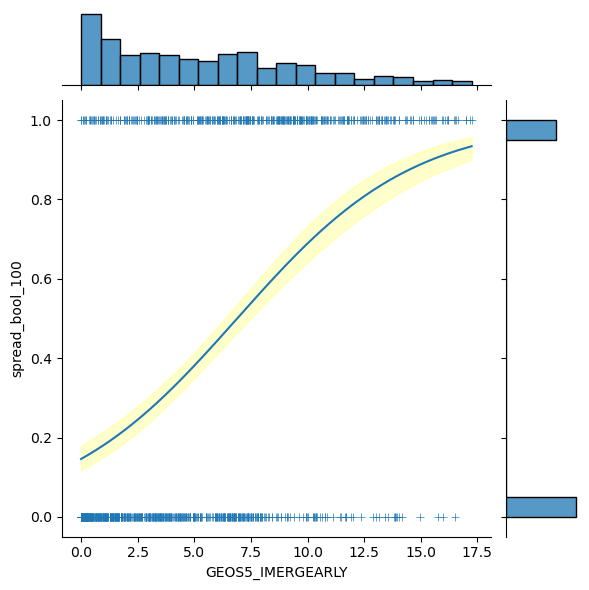

No growth detected, no values over nan in GEOS5_IMERGEARLY
['Model_mean'] had the best accuracy (0.7132936507936508). Other scores were: 
          0                 1
0  0.000000              Null
1  0.713294        Model_mean
2  0.547619  most_common_null
Mean model's accuracy is between 0.7271825396825397 and 0.7113095238095237


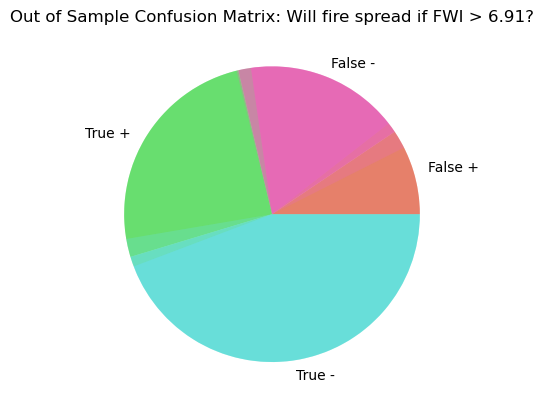

In [12]:

model = make_logit(fire_delta = fire, fire_test = fire_test, x= 'GEOS5_IMERGEARLY', y = "spread_bool_100")






### 70% smallest fires -- 2km growth not different from Null. spread 0 -1  the model does beat out the null. (GEOS5_IMERGEEARLY)
## 90% smallest fires -- 2 km growth does just beat out the null. (GEOS5_IMERGEEARLY) 4km growth doesn't beat the null. 


### Testing in/out of sample sorted by space
### 2km spread -- mean safely beat the null 4km looses to the null. (GEOS5_IMERGEEARLY)

## Testing "life stage" of fire
## 2km spread -- mean beats null. null beats out mean. 6km null also beats out mean



## Fractional change tests
## fractional change > 0.1 was not significant (GEOS5_IMERGEEARLY)
## fractional change > 0.05 Was significant (GEOS5_IMERGEEARLY)



In [13]:
# Per fire logit distribution


def save_model(model, model_type, model_dir):
    """Save a model and record its metadata."""
    timestamp = datetime.now().strftime("%Y%m%d")
    model_filename = f"{model_type}_{timestamp}.pkl"
    model_path = os.path.join(model_dir, model_filename)
    
    # Save the model
    with open(model_path, 'wb') as f:
        pickle.dump(model, f)
    
    metadata = {}
    # Add model-specific metrics
    metadata.update({
        'aic': model.aic,
        'bic': model.bic,
        'pseudo_r2': model.prsquared
    })
    
    
    # Update registry
    registry_path = os.path.join(model_dir, f"{model_type}_{timestamp}_model_registry.csv")
    if os.path.exists(registry_path):
        registry = pd.read_csv(registry_path)
        registry = pd.concat([registry, pd.DataFrame([metadata])], ignore_index=True)
    else:
        registry = pd.DataFrame([metadata])
    
    registry.to_csv(registry_path, index=False)
    return model_path

def get_model(query=None, model_path = None):
    """Retrieve a model based on query criteria or get the latest."""
    registry_path = os.path.join(model_dir, "model_registry.csv")
    if not os.path.exists(registry_path):
        raise FileNotFoundError("Model registry not found")
    
    registry = pd.read_csv(registry_path)
    
    if query:
        # Example: query = {'model_type': 'logit', 'metric': 'aic', 'operation': 'min'}
        if 'metric' in query and 'operation' in query:
            if query['operation'] == 'min':
                idx = registry[query['metric']].idxmin()
            elif query['operation'] == 'max':
                idx = registry[query['metric']].idxmax()
            model_path = registry.loc[idx, 'filepath']
        else:
            # Filter by other criteria
            for key, value in query.items():
                if key in registry.columns:
                    registry = registry[registry[key] == value]
            if len(registry) == 0:
                raise ValueError("No models match the query criteria")
            model_path = registry.iloc[0]['filepath']
    elif model_path is None:
        print("Error: Need a Query or a model_path")
        
    
    # Load and return the model
    return load_model(model_path)
    

y = "spread_bool_100"
import warnings
def make_logit_one_fire(df, x='GEOS5_IMERGEARLY', y= y ):
    fire_delta = df[[x, y]].drop_duplicates().dropna()
    fid = df.fireID.iloc[0]
    print(fid)

    if len(fire_delta[y].unique()) <= 1 or len(fire_delta[x].unique()) <= 1:
        df[f"{x}_thresh_{y}"] = None
        return df

    try:
        with warnings.catch_warnings(record=True) as w:
            formula = f"{y} ~ {x}"
            model = smf.logit(formula, data=fire_delta).fit()
            if len(w) > 0:
                print(w)
                print(f"Warning in fitting the model: {e}")
                df.loc[:, f"{x}_thresh_{y}"] = None
                path = None
            else:
                path = save_model(model = model, model_type = f"{fid}_{x}_vs_{y}", model_dir = os.path.abspath("logit_model_objects"))
                df.loc[:, f"path_{x}_thresh_{y}"] = path

    except Exception as e:
        print(f"Error fitting the model: {e}")
        df.loc[:, f"{x}_thresh_{y}"] = None
        path = None
        
        return df

    fire_delta['fitted'] = model.fittedvalues
    predictions = model.get_prediction(fire_delta)
    fire_delta['predicted'] = predictions.predicted
    fire_delta['conf_int_low'], fire_delta['conf_int_high'] = predictions.conf_int().T

    thresh = 0.5
    will_grow = fire_delta[fire_delta['predicted'] > thresh][x].min()

    mean = calc_confusion_matrix_individual(fire_delta=fire_delta, fire_test=None, thresh=thresh, x=x, y=y, pred_column="predicted")

    if mean is None:
        df[f"{x}_thresh_{y}"] = None
        return df

    fire_delta['most_common'] = fire_delta[y].mode().iloc[0]
    mean_common = common_confusion_matrix(fire_delta=fire_delta, fire_test=None, thresh=thresh, x=x, y=y, pred_column="most_common")

    percent_right = (mean[3] + mean[2]) / 1
    percent_right_common = (mean_common[3] + mean_common[2]) / 1

    scores = [percent_right, percent_right_common]
    score_names = ["Model_mean", "most_common_null"]
    scores_df = pd.DataFrame(list(zip(scores, score_names)), columns=['Score', 'Model'])

    df[f"{x}_thresh_{y}"] = will_grow if scores_df.iloc[0]['Score'] > scores_df.iloc[1]['Score'] else None

    return df


In [14]:
big_fr = fire3[fire3.fireID == '226'] ## Big fire
mid_fr2 = fire3[fire3.fireID == '3718'] ## mid fire 80 -- wait we didn;t catch any change here. 
mid_fr = fire3[fire3.fireID == '3423']

tmp = make_logit_one_fire(mid_fr2, x= 'GEOS5_IMERGEARLY', y = y)

3718


/srv/conda/envs/notebook/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [15]:
fire_df = fire3.copy()


long_fires = fire_df.groupby("fireID").duration.max().reset_index()
long_fires = long_fires[long_fires.duration > 6].fireID

fire_df = fire_df[fire_df.fireID.isin(long_fires)]
fire_df = fire_df.groupby("fireID").apply(make_logit_one_fire).reset_index(drop = True)

fire_df2 = fire_df.copy()
y = "spread_bool_frac_05"
fire_df = fire_df.groupby("fireID").apply(lambda x: make_logit_one_fire(x, y=y)).reset_index(drop = True)

1034
         Current function value: 0.000000
         Iterations: 35
[<warnings.WarningMessage object at 0x7f4598aaea20>, <warnings.WarningMessage object at 0x7f4598aafdd0>]
Error fitting the model: cannot access local variable 'e' where it is not associated with a value
1082
Optimization terminated successfully.
         Current function value: 0.271432
         Iterations 8
1088
Optimization terminated successfully.
         Current function value: 0.506943
         Iterations 6
1089
         Current function value: inf
         Iterations: 35
Error fitting the model: Singular matrix
1101
Optimization terminated successfully.
         Current function value: 0.266719
         Iterations 8
1105
Optimization terminated successfully.
         Current function value: 0.312124
         Iterations 7
1166
Optimization terminated successfully.
         Current function value: 0.272517
         Iterations 7
1174
Optimization terminated successfully.
         Current function value: 0.149508

/tmp/ipykernel_2413/1301832871.py:8: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
/tmp/ipykernel_2413/1301832871.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


1088
Optimization terminated successfully.
         Current function value: 0.454565
         Iterations 6
1089
Optimization terminated successfully.
         Current function value: 0.230841
         Iterations 8
1101
Optimization terminated successfully.
         Current function value: 0.266719
         Iterations 8
1105
Optimization terminated successfully.
         Current function value: 0.427088
         Iterations 6
1166
Optimization terminated successfully.
         Current function value: 0.263263
         Iterations 8
1174
Optimization terminated successfully.
         Current function value: 0.230217
         Iterations 8
1271
Optimization terminated successfully.
         Current function value: 0.472369
         Iterations 7
1321
         Current function value: 0.000000
         Iterations: 35
Error fitting the model: cannot access local variable 'e' where it is not associated with a value
1324
         Current function value: 0.000000
         Iterations: 35
[<warnings.

/tmp/ipykernel_2413/1301832871.py:12: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
/tmp/ipykernel_2413/1301832871.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


In [16]:

y = "spread_bool_100"

y_col_name = f'GEOS5_IMERGEARLY_thresh_{y}'


pct_fire_sig = len(fire_df[~fire_df[y_col_name].isna()].fireID.unique()) / len(fire_df.fireID.unique())
pct_fire_sig_total = len(fire_df[~fire_df[y_col_name].isna()].fireID.unique()) / len(fire3.fireID.unique())

print(f'Percent of fires that logit that found a significant spread threoshold for {y} {pct_fire_sig }')


# pct_fire_sig2 = len(fire_df2[~fire_df2[y_col_name].isna()].fireID.unique()) / len(fire_df.fireID.unique())
# pct_fire_sig_total2 = len(fire_df2[~fire_df2[y_col_name].isna()].fireID.unique()) / len(fire3.fireID.unique())

# print(f'Percent of fires that logit that found a significant spread threoshold for {y} {pct_fire_sig2 }')



# pct_fire_sig = len(fire_df[~fire_df.GEOS5_IMERGEARLY_thresh_spread_bool_200.isna()].fireID.unique()) / len(fire_df.fireID.unique())

# print(f'Percent of fires that logit that found a significant spread threoshold for spread_bool_200 {pct_fire_sig }')

Percent of fires that logit that found a significant spread threoshold for spread_bool_100 0.5584415584415584


Text(0.5, 1.0, ' N = 43 fires, 56.00000000000001% of total fires. Logit models fit against GEOS5 + IMERGE')

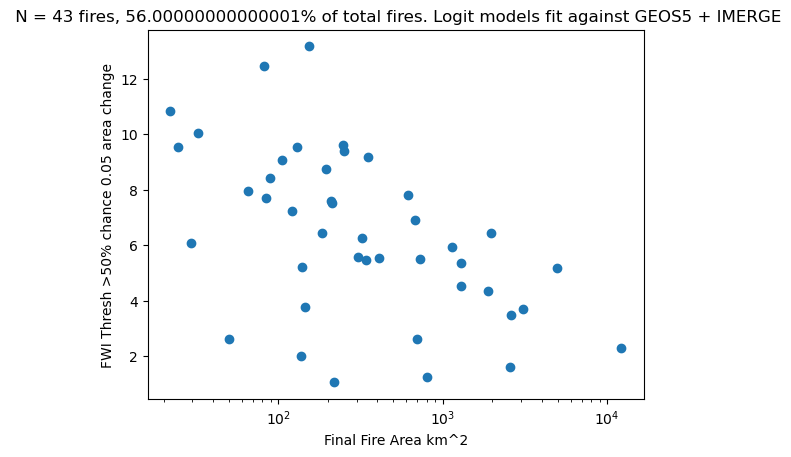

In [17]:
plt.scatter(x = fire_df.groupby("fireID").farea.max(), y = fire_df.groupby('fireID')[y_col_name].max())
plt.xlabel("Final Fire Area km^2")
#plt.ylabel(f"FWI Threshold for >50% chance of {y}")
plt.ylabel(f"FWI Thresh >50% chance 0.05 area change")
plt.xscale("log")
plt.title(f" N = {len(fire_df[~fire_df[y_col_name].isna()].fireID.unique())} fires, {round(pct_fire_sig, 2) * 100}% of total fires. Logit models fit against GEOS5 + IMERGE")

Text(0.5, 0, 'FWI Thresh >50% chance 1 km^2 growth')

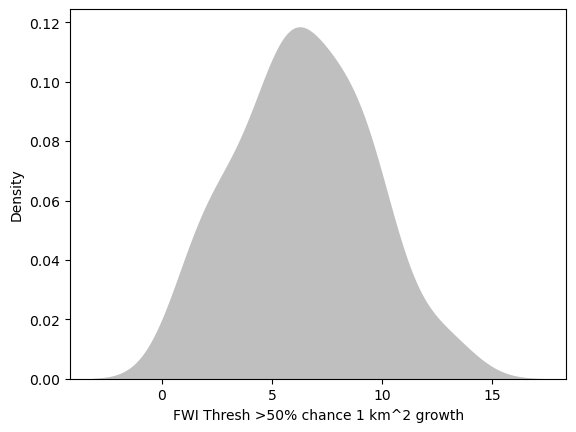

In [18]:
sns.kdeplot(fire_df.groupby('fireID')[y_col_name].max(), fill=True, common_norm=False,  color = "gray", alpha=.5, linewidth=0, label = "Individual fires")
plt.xlabel(f"FWI Thresh >50% chance 1 km^2 growth")

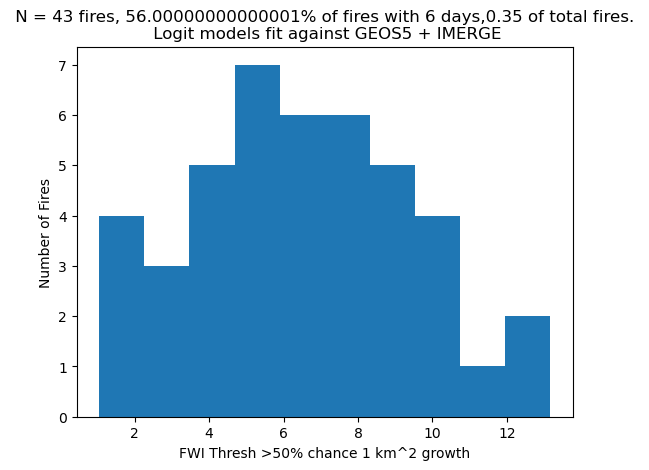

In [19]:
plt.hist( fire_df.groupby('fireID')[y_col_name].max())
plt.ylabel("Number of Fires")
#plt.ylabel(f"FWI Threshold for >50% chance of {y}")
#plt.xlabel(f"FWI Thresh >50% chance 0.05 area change")
plt.xlabel(f"FWI Thresh >50% chance 1 km^2 growth")
#plt.xscale("log")
plt.title(f" N = {len(fire_df[~fire_df[y_col_name].isna()].fireID.unique())} fires, {round(pct_fire_sig, 2) * 100}% of fires with 6 days,{round(pct_fire_sig_total, 2)} of total fires. \n Logit models fit against GEOS5 + IMERGE")

plt.savefig("some_figs/logit_model_plots/histogram_individual_fire_logit_model.png")

In [20]:
# plt.scatter(x = fire_df.groupby("fireID").farea.max(), y = fire_df.groupby('fireID')[y_col_name].max())
# plt.xlabel("Final Fire Area km^2")
# #plt.ylabel(f"FWI Threshold for >50% chance of {y}")
# plt.ylabel(f"FWI Thresh >50% chance 0.05 area change")
# plt.xscale("log")
# plt.title(f" N = {len(fire_df[~fire_df[y_col_name].isna()].fireID.unique())} fires, {round(pct_fire_sig, 2) * 100}% of total fires. Logit models fit against GEOS5 + IMERGE")



### color by lat, supression, time of ignition, and fuels if I can swing it. 

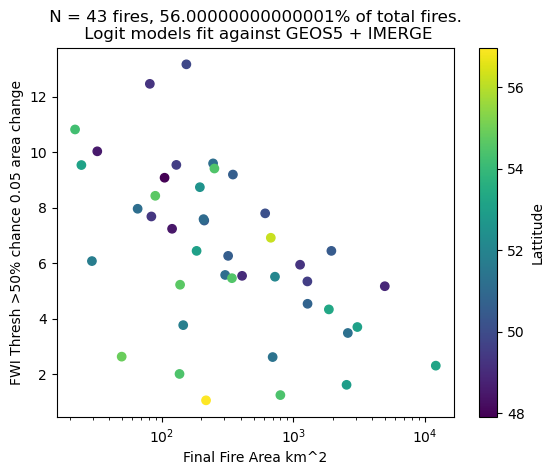

In [21]:
plt.scatter(x = fire_df.groupby("fireID").farea.max(), y = fire_df.groupby('fireID')[y_col_name].max(), c = fire_projected[fire_projected.fireID.isin(fire_df.fireID.unique())].groupby('fireID')["Lat"].max())
plt.xlabel("Final Fire Area km^2")
#plt.ylabel(f"FWI Threshold for >50% chance of {y}")
plt.ylabel(f"FWI Thresh >50% chance 0.05 area change")
plt.xscale("log")
plt.title(f" N = {len(fire_df[~fire_df[y_col_name].isna()].fireID.unique())} fires, {round(pct_fire_sig, 2) * 100}% of total fires. \n Logit models fit against GEOS5 + IMERGE")
plt.colorbar(label = "Lattitude")

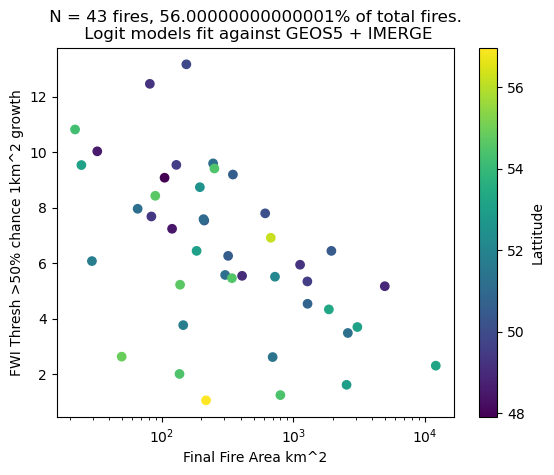

In [22]:
y = "spread_bool_100"
y_col_name = f'GEOS5_IMERGEARLY_thresh_{y}'

plt.scatter(x = fire_df.groupby("fireID").farea.max(), y = fire_df.groupby('fireID')[y_col_name].max(), c = fire_projected[fire_projected.fireID.isin(fire_df.fireID.unique())].groupby('fireID')["Lat"].max())
plt.xlabel("Final Fire Area km^2")
#plt.ylabel(f"FWI Threshold for >50% chance of {y}")
#plt.ylabel(f"FWI Thresh >50% chance 0.05 area change")
plt.ylabel(f"FWI Thresh >50% chance 1km^2 growth")
plt.xscale("log")
plt.title(f" N = {len(fire_df[~fire_df[y_col_name].isna()].fireID.unique())} fires, {round(pct_fire_sig, 2) * 100}% of total fires. \n Logit models fit against GEOS5 + IMERGE")
plt.colorbar(label = "Lattitude")

plt.savefig(f"some_figs/logit_model_plots/Threshholds_vs_fire_size_{y_col_name}.png")



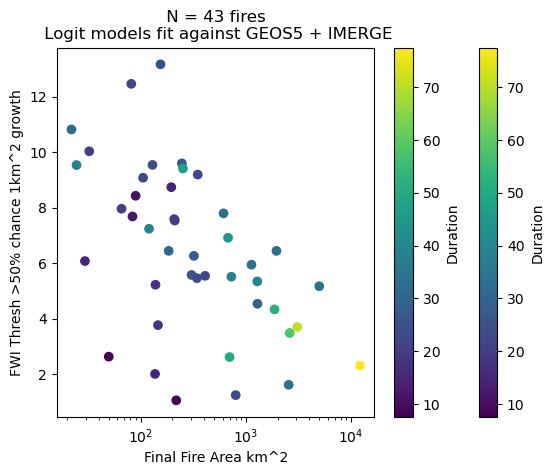

In [23]:
y = "spread_bool_100"
y_col_name = f'GEOS5_IMERGEARLY_thresh_{y}'

plt.scatter(x = fire_df.groupby("fireID").farea.max(), y = fire_df.groupby('fireID')[y_col_name].max(), c = fire_projected[fire_projected.fireID.isin(fire_df.fireID.unique())].groupby('fireID')["duration"].max())
plt.xlabel("Final Fire Area km^2")
#plt.ylabel(f"FWI Threshold for >50% chance of {y}")
#plt.ylabel(f"FWI Thresh >50% chance 0.05 area change")
plt.ylabel(f"FWI Thresh >50% chance 1km^2 growth")
plt.xscale("log")
#plt.title(f" N = {len(fire_df[~fire_df[y_col_name].isna()].fireID.unique())} fires, {round(pct_fire_sig, 2) * 100}% of total fires. \n Logit models fit against GEOS5 + IMERGE")
plt.title(f" N = {len(fire_df[~fire_df[y_col_name].isna()].fireID.unique())} fires \n Logit models fit against GEOS5 + IMERGE")
plt.colorbar(label = "Duration")
plt.colorbar(label = "Duration")

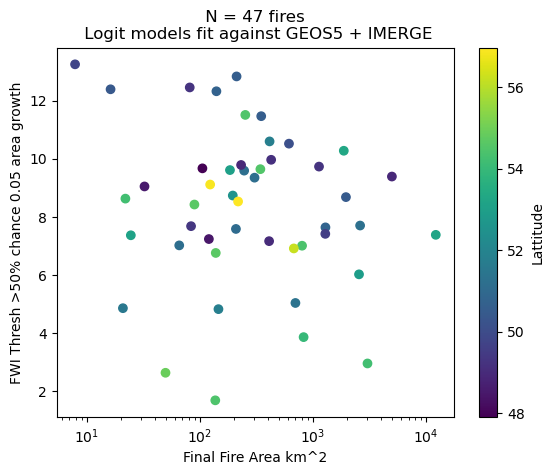

In [24]:


y = "spread_bool_frac_05"
y_col_name = f'GEOS5_IMERGEARLY_thresh_{y}'
plt.scatter(x = fire_df.groupby("fireID").farea.max(), y = fire_df.groupby('fireID')[y_col_name].max(), c = fire_projected[fire_projected.fireID.isin(fire_df.fireID.unique())].groupby('fireID')["Lat"].max())
plt.xlabel("Final Fire Area km^2")
#plt.ylabel(f"FWI Threshold for >50% chance of {y}")
plt.ylabel(f"FWI Thresh >50% chance 0.05 area growth")
#plt.ylabel(f"FWI Thresh >50% chance 0.05 area change")
plt.xscale("log")
#plt.title(f" N = {len(fire_df[~fire_df[y_col_name].isna()].fireID.unique())} fires, {round(pct_fire_sig, 2) * 100}% of total fires. \n Logit models fit against GEOS5 + IMERGE")
plt.title(f" N = {len(fire_df[~fire_df[y_col_name].isna()].fireID.unique())} fires \n Logit models fit against GEOS5 + IMERGE")
plt.colorbar(label = "Lattitude")
plt.savefig(f"some_figs/logit_model_plots/Threshholds_vs_fire_size_{y_col_name}.png")


In [25]:
from matplotlib import dates
import datetime
from datetime import datetime

# plt.scatter(x = fire_df.groupby("fireID").farea.max(), y = fire_df.groupby('fireID')[y_col_name].max(), c = fire_df[fire_df.is_ig == True].t.astype("datetime64[ns]"))#.astype("int") )
# plt.xlabel("Final Fire Area km^2")
# #plt.legend()
# #plt.ylabel(f"FWI Threshold for >50% chance of {y}")
# plt.ylabel(f"FWI Thresh >50% chance 0.05 area change")
# plt.xscale("log")
# plt.title(f" N = {len(fire_df[~fire_df[y_col_name].isna()].fireID.unique())} fires, {round(pct_fire_sig, 2) * 100}% of total fires. \n Logit models fit against GEOS5 + IMERGE")
# cbar = plt.colorbar(label = "Time of Ignition")

# ticks = cbar.get_ticks()

# # Convert integer ticks to datetime objects
# datetimes = [datetime.fromtimestamp(t // 10**9) for t in ticks]

# # Format the colorbar ticks as HH:MM:SS
# cbar.ax.yaxis.set_major_formatter(dates.DateFormatter('%m-%d'))

# # Update the tick labels with the formatted datetimes
# cbar.set_ticks(ticks)
# cbar.set_ticklabels(datetimes)


# # Update the tick labels with the formatted datetimes


## Adding in catagorial data to logit model

In [26]:
def make_logit_cat(fire_delta, fire_test, x, y, c):
    #fire_delta = fire_delta[[x, y]].dropna()
    fire_delta = fire_delta[[x, y,c]].drop_duplicates()
    fire_delta = fire_delta[[x , y,c]].dropna()

    fire_test = fire_test[[x, y,c]].drop_duplicates()
    fire_test = fire_test[[x, y,c]].dropna()
    
    formula = f"{y} ~ {x}:C({c})"

    
    pre_model = smf.logit(formula, data=fire_delta)
    model = pre_model.fit()

    #model_null = baseline_null_model(fire_delta, x = x, y = y)

    #print(f"Model has AIC of {round(model.aic, 3)}, null model aic of {round(model_null.aic, 3)}") 
    
    
    sns.jointplot(data=fire_delta, x= x, y=y, marker="+",  dropna = True, marginal_kws = {"bins": 20}) #  marginal_kws = {"log_scale": True} 
    #t.ax_marg_y.set_yscale("log")
    max_of_max = round(max(fire_delta[x].max(), fire_delta[y].max()))
    min_of_min = round(min(fire_delta[x].min(), fire_delta[y].min()))
    fire_delta['fitted'] = model.fittedvalues
    #fire_delta['residuals'] = model.resid_response
    fire_delta = fire_delta.sort_values(by = x)
    predictions = model.get_prediction(fire_delta) #df, transform = False
    fire_delta['predicted'] = predictions.predicted
    fire_delta['conf_int_low'], fire_delta['conf_int_high'] = predictions.conf_int().T
    #return(fire_delta)
    for i,n in enumerate(fire_delta[c].unique()):
        #print(n)
        row_mask = fire_delta[c] == n
        #print(fire_delta[row_mask])
        plt.fill_between(fire_delta.loc[row_mask, x], fire_delta.loc[row_mask, 'conf_int_low'], fire_delta.loc[row_mask, 'conf_int_high'], alpha=0.2, color = "yellow")
        sns.lineplot(x=x, y='predicted', data=fire_delta[row_mask], legend = False, label = n)
    plt.legend()
    plt.savefig("some_figs/logit_model_plots/supression_logit_model.png")
    plt.show()
    
    for i,n in enumerate(fire_delta[c].unique()):
        fire_delta_sub = fire_delta[fire_delta[c] == n]
        fire_test_sub = fire_test[fire_test[c] == n]
        
        thresh = 0.5
        will_grow = fire_delta_sub[fire_delta_sub['predicted'] > thresh][x].min()
        
        mean = calc_confusion_matrix(fire_delta = fire_delta_sub, fire_test = fire_test_sub, thresh = thresh, x = x, y = y, pred_column= "predicted")
        upper = calc_confusion_matrix(fire_delta = fire_delta_sub, fire_test = fire_test_sub, thresh = thresh, x = x, y = y, pred_column= "conf_int_high")
        lower = calc_confusion_matrix(fire_delta = fire_delta_sub, fire_test = fire_test_sub, thresh = thresh, x = x, y = y, pred_column= "conf_int_low")
    
        # ## Make null models
        # predictions_null = model_null.get_prediction(fire_delta_sub)
        # fire_delta_sub['predicted_null'] = predictions_null.predicted
    
        
    #     mean_null = calc_confusion_matrix(fire_delta_sub = fire_delta_sub, fire_test = fire_test_sub, thresh = thresh, x = x, y = y, pred_column= "predicted_null")
    
        fire_delta_sub.loc[:, 'most_common'] = fire_delta_sub[y].mode().iloc[0]
        if len(fire_delta_sub[y].mode()) > 1:
            print("Equal 0's and 1's in bool. Assuming 0. ")
        fire_test_sub.loc[:, 'most_common'] = fire_test_sub[y].mode().iloc[0]
    #     #return(fire_delta_sub)
        mean_common = common_confusion_matrix(fire_delta = fire_delta_sub, fire_test = fire_test_sub, thresh = thresh, x = x, y = y, pred_column= "most_common")
    
    #     percent_right_null = (mean_null[2] + mean_null[3]) / 1
        percent_right = (mean[3] + mean[2]) / 1
        percent_right_upper = (upper[3] + upper[2]) / 1
        percent_right_lower = (lower[3] + lower[2]) / 1
        percent_right_common = (mean_common[3] + mean_common[2]) / 1
    
        # if(percent_right > any([percent_right_null, percent_right_common])):
        #     print(f"Model accuracy ({percent_right}) better than null ({percent_right_null}), consistancy model ({percent_right_common}))")
        #     if((percent_right_null > any([percent_right_upper, percent_right_lower])) or (percent_right_common > any([percent_right_upper, percent_right_lower]))):
        #         print("But accuracy is within range of model error.")
        # else:
        #scores = [percent_right_null, percent_right, percent_right_common]
        scores = [percent_right, percent_right_common]
        #score_names = ["Null", "Model_mean", "most_common_null"]
        score_names = [ "Model_mean", "most_common_null"]
        scores_df = pd.DataFrame(zip(scores, score_names))
        print(f" For {n}: /n {scores_df[scores_df.loc[:, 0] == scores_df.loc[:, 0].max()].loc[:, 1].values} had the best accuracy ({scores_df.loc[:, 0].max()}). Other scores were: ")
        print(scores_df)
    
    #     print(f"Mean model's accuracy is between {percent_right_upper} and {percent_right_lower}")
            
    # #     #return(scores_df)
        
    
    # #rates = np.array(mean)
        
    #     mylabels = ["False +", "False -", "True +", "True -"]
    #     mycolors = ["#dd4626", "#dd2695", "#22d12c", "#22d1c9"]
        
    
    #     plt.pie(mean, labels = mylabels, wedgeprops={"alpha": 0.5}, colors = mycolors)
    #     plt.pie(upper, wedgeprops={"alpha": 0.2}, colors = mycolors)
    #     plt.pie(lower, wedgeprops={"alpha": 0.2}, colors = mycolors)
        
    #     plt.title(f"Out of Sample Confusion Matrix: Will fire spread if FWI > {round(will_grow, 2)}?")
    #     #plt.pie(y, )
    #     plt.show() 
        
        ## Test against some null models    
        #print(f"Model has AIC of {model.aic}, null model aic of {model_null.aic}") 
    
    return(model)

In [27]:
fire3.columns

Index(['fireID', 't', 'geometry', 'Unnamed: 0', 'mergeid', 'ftype', 'n_pixels',
       'n_newpixels', 'farea', 'fperim', 'flinelen', 'duration', 'pixden',
       'meanFRP', 't_st', 't_ed', 'isignition', 't_inactive', 'isactive',
       'isdead', 'mayreactivate', 'geom_counts', 'low_confidence_grouping',
       'region', 'primarykey', 'csv_geometry', 'GEOS-5.IMERGEARLY', 'FWI',
       'FWI_lead_1', 'FWI_lead_2', 'FWI_lead_3', 'FWI_lead_4', 'FWI_lead_5',
       'FWI_lead_6', 'FWI_lead_7', 'FWI_lead_8', 'farea_diff_stand',
       'corrected_flinelen', 'frac_change', 'flinelen_frac_change',
       'fperim_shifted', 'flinelen_diff', 'fperim_diff', 'farea_shifted',
       'meanFRP_shifted', 'flinelen_shifted', 'n_newpixels_shifted',
       'GEOS5_IMERGEARLY_shifted', 'FWI_shifted', 'FWI_lead_1_shifted',
       'FWI_forecast_average', 'FWI_forecast_average_shifted',
       'corrected_shifted_flinelen', 'flinelen_shifted_frac_change',
       'farea_shifted_exp', 'meanFRP_shifted_exp', 'flinele

Optimization terminated successfully.
         Current function value: 0.527736
         Iterations 6


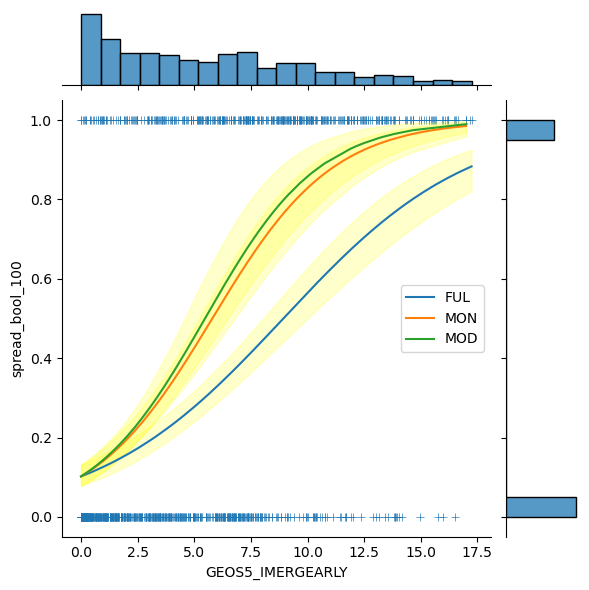

 For FUL: /n ['Model_mean'] had the best accuracy (0.7238605898123325). Other scores were: 
          0                 1
0  0.723861        Model_mean
1  0.530831  most_common_null
 For MON: /n ['Model_mean'] had the best accuracy (0.7527675276752768). Other scores were: 
          0                 1
0  0.752768        Model_mean
1  0.597786  most_common_null
 For MOD: /n ['Model_mean'] had the best accuracy (0.7686567164179104). Other scores were: 
          0                 1
0  0.768657        Model_mean
1  0.634328  most_common_null


/tmp/ipykernel_2413/2161782869.py:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/tmp/ipykernel_2413/2161782869.py:62: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/tmp/ipykernel_2413/2161782869.py:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/tmp/ipykernel_2413/21

<Figure size 640x480 with 0 Axes>

In [44]:
#field_response_type
foo = fire3.groupby("fireID").field_response_type.unique().reset_index()
multi_sup_ids = foo[foo.field_response_type.apply(len) == 2].fireID.unique()
model = make_logit_cat(fire_delta = fire[~fire.fireID.isin(multi_sup_ids)], fire_test = fire_test[~fire_test.fireID.isin(multi_sup_ids)], x = "GEOS5_IMERGEARLY", y = "spread_bool_100", c = 'field_response_type' )
plt.savefig("some_figs/logit_model_plots/supression_responce.png")


In [29]:



def plot_logit(fire_delta, fire_test, x, y):
    #fire_delta = fire_delta[[x, y]].dropna()
    fire_delta = fire_delta[[x, y]].drop_duplicates() ## Does this get rid of "no-spread days?"
    fire_delta = fire_delta[[x , y]].dropna()

    fire_test = fire_test[[x, y]].drop_duplicates()
    fire_test = fire_test[[x, y]].dropna()
    
    formula = f"{y} ~ {x}"

    
    pre_model = smf.logit(formula, data=fire_delta)
    model = pre_model.fit()

    model_null = baseline_null_model(fire_delta, x = x, y = y)

    #print(f"Model has AIC of {round(model.aic, 3)}, null model aic of {round(model_null.aic, 3)}") 
    
    
    #sns.jointplot(data=fire_delta, x= x, y=y, marker="+",  dropna = True, marginal_kws = {"bins": 20}) #  marginal_kws = {"log_scale": True} 
    #t.ax_marg_y.set_yscale("log")
    max_of_max = round(max(fire_delta[x].max(), fire_delta[y].max()))
    min_of_min = round(min(fire_delta[x].min(), fire_delta[y].min()))
    fire_delta['fitted'] = model.fittedvalues
  
    #fire_delta['residuals'] = model.resid_response
    fire_delta = fire_delta.sort_values(by = x)
    predictions = model.get_prediction(fire_delta) #df, transform = False
    fire_delta['predicted'] = predictions.predicted
   
    fire_delta['conf_int_low'], fire_delta['conf_int_high'] = predictions.conf_int().T
    fig, ax1 = plt.subplots( ) # figsize=(12, 5)
    
    sns.lineplot(x=x, y='predicted', data=fire_delta, ax = ax1, legend = False, label = "Global Model")
    ax2 = ax1.twinx()
    #ax2.fill_between(fire_delta[x], fire_delta['conf_int_low'], fire_delta['conf_int_high'], alpha=0.2, color = "yellow")
    ax1.set_ylim(0, 1)
    ax2.set_ylim(0, 1)
    
    #plt.savefig("some_figs/logit_model_plots/no_catatgorical_logit_model.png")
    #plt.show()
    
    thresh = 0.5
    will_grow = fire_delta[fire_delta['predicted'] > thresh][x].min()
    print(f"When FWI is grater than {will_grow}, fires have a >50% chanse of spreading {y}")
    
    mean = calc_confusion_matrix(fire_delta = fire_delta, fire_test = fire_test, thresh = thresh, x = x, y = y, pred_column= "predicted")
    upper = calc_confusion_matrix(fire_delta = fire_delta, fire_test = fire_test, thresh = thresh, x = x, y = y, pred_column= "conf_int_high")
    lower = calc_confusion_matrix(fire_delta = fire_delta, fire_test = fire_test, thresh = thresh, x = x, y = y, pred_column= "conf_int_low")

    ## Make null models
    predictions_null = model_null.get_prediction(fire_delta)
    fire_delta['predicted_null'] = predictions_null.predicted

    
    mean_null = calc_confusion_matrix(fire_delta = fire_delta, fire_test = fire_test, thresh = thresh, x = x, y = y, pred_column= "predicted_null")

    fire_delta.loc[:, 'most_common'] = fire_delta[y].mode().iloc[0]
    if len(fire_delta[y].mode()) > 1:
        print("Equal 0's and 1's in bool. Assuming 0. ")
    fire_test.loc[:, 'most_common'] = fire_test[y].mode().iloc[0]
    if len(fire_test[y].mode()) > 1:
        print("Equal 0's and 1's in bool. Assuming 0. ")
    #return(fire_delta)
    mean_common = common_confusion_matrix(fire_delta = fire_delta, fire_test = fire_test, thresh = thresh, x = x, y = y, pred_column= "most_common")

    percent_right_null = (mean_null[2] + mean_null[3]) / 1
    percent_right = (mean[3] + mean[2]) / 1
    percent_right_upper = (upper[3] + upper[2]) / 1
    percent_right_lower = (lower[3] + lower[2]) / 1
    percent_right_common = (mean_common[3] + mean_common[2]) / 1

    # if(percent_right > any([percent_right_null, percent_right_common])):
    #     print(f"Model accuracy ({percent_right}) better than null ({percent_right_null}), consistancy model ({percent_right_common}))")
    #     if((percent_right_null > any([percent_right_upper, percent_right_lower])) or (percent_right_common > any([percent_right_upper, percent_right_lower]))):
    #         print("But accuracy is within range of model error.")
    # else:
    scores = [percent_right_null, percent_right, percent_right_common]
    score_names = ["Null", "Model_mean", "most_common_null"]
    scores_df = pd.DataFrame(zip(scores, score_names))
    print(f"{scores_df[scores_df.loc[:, 0] == scores_df.loc[:, 0].max()].loc[:, 1].values} had the best accuracy ({scores_df.loc[:, 0].max()}). Other scores were: ")
    print(scores_df)

    print(f"Mean model's accuracy is between {percent_right_upper} and {percent_right_lower}")

    
    ## Test against some null models    
    #print(f"Model has AIC of {model.aic}, null model aic of {model_null.aic}") 
    
    return(fig, (ax1, ax2))




Optimization terminated successfully.
         Current function value: 0.566331
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.668030
         Iterations 4
When FWI is grater than 6.91019992068806, fires have a >50% chanse of spreading spread_bool_100
No growth detected, no values over nan in GEOS5_IMERGEARLY
['Model_mean'] had the best accuracy (0.7132936507936508). Other scores were: 
          0                 1
0  0.000000              Null
1  0.713294        Model_mean
2  0.547619  most_common_null
Mean model's accuracy is between 0.7271825396825397 and 0.7113095238095237


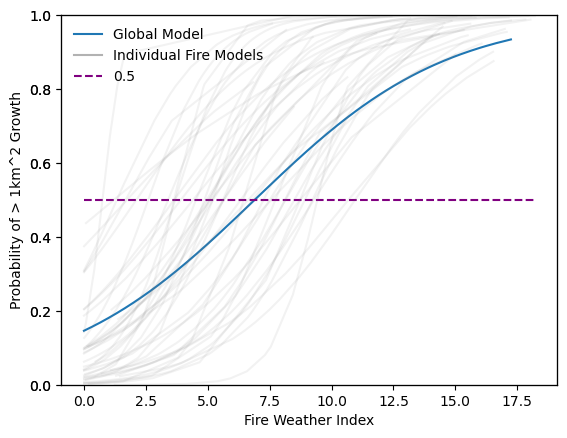

In [30]:
def load_model(filepath):
    with open(filepath, 'rb') as f:
        return pickle.load(f)

x= 'GEOS5_IMERGEARLY'
y = "spread_bool_100"

fig, (ax1, ax2) = plot_logit(fire_delta = fire, fire_test = fire_test, x= 'GEOS5_IMERGEARLY', y = "spread_bool_100")
ax1.set_ylabel("Probability of > 1km^2 Growth")
ax1.set_xlabel("Fire Weather Index")
ax1.plot([None], [None], color = "grey",  alpha = 0.6, label = "Individual Fire Models")
ax1.hlines(0.5, xmin = 0, xmax =  fire_df[x].max(), color = "purple", linestyle = "dashed", label = "0.5")
ax1.legend(framealpha = 0, loc = 'upper left')


ax3 = ax2.twinx()
for fid in fire_df[~fire_df.GEOS5_IMERGEARLY_thresh_spread_bool_100.isnull()].fireID.unique():
    path = fire_df[fire_df.fireID == fid].path_GEOS5_IMERGEARLY_thresh_spread_bool_100.iloc[0]
    model = load_model(path)
    sub_df = fire_df[fire_df.fireID == fid]
    sub_df = sub_df[[x, y]].drop_duplicates()
    sub_df = sub_df[[x, y]].dropna()
    sub_df = sub_df.sort_values(by = x)
    predictions = model.get_prediction(sub_df)
    sub_df.loc[:, "fitted"] = model.fittedvalues
    sub_df.loc[:, "predicted"] =  predictions.predicted
    ax3.plot(sub_df[f'{x}'], sub_df.predicted, color = "grey",  alpha = 0.1, label = f"{fid}") # color = "grey", 
    ax3.set_ylim(0, 1)
    #ax3.yaxis.set_major_formatter(plt.NullFormatter())
    ax3.get_yaxis().set_visible(False)
    ax3.yaxis
    #ax3.hlines(0.5, color = "purple", linestyle = "dashed", label = "0.5")
#ax3.legend()
plt.savefig("some_figs/logit_model_plots/Global_and_individual_logit.svg")
plt.show()


# bad = 1034 1321 1324 2380 245 269 2667

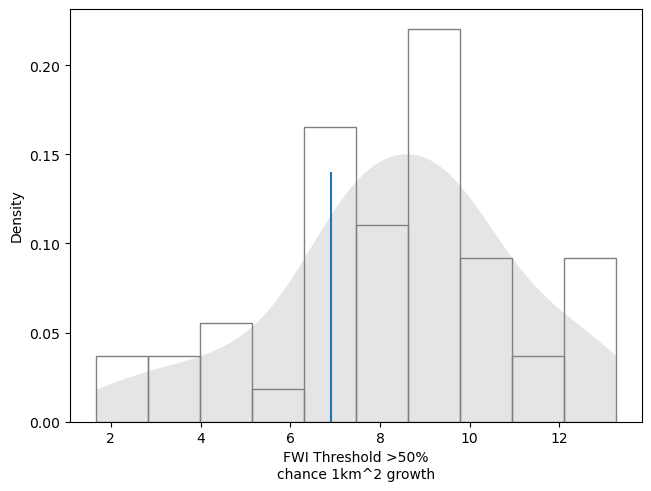

In [31]:
tot_sig_fires = len(fire_df.groupby('fireID')[y_col_name].max())
def formatter(x, pos, tot = tot_sig_fires):
    del pos
    return str(x*tot)


factor = 2

style = {'facecolor': 'none', 'edgecolor': 'gray'}
fig, ax = plt.subplots(layout="constrained")
ax.hist( fire_df.groupby('fireID')[y_col_name].max(), density=True, **style)
#ax.set_axis_off()
ax2.hist( fire_df.groupby('fireID')[y_col_name].max(), **style)
#ax.set_ylabel("Number of Fires")
#ax.set_xlabel(f"FWI Thresh >50% chance 1 km^2 growth")
#ax.set_title(f" N = {len(fire_df[~fire_df[y_col_name].isna()].fireID.unique())} fires, {round(pct_fire_sig, 2) * 100}% of fires with 6 days,{round(pct_fire_sig_total, 2)} of total fires. \n Logit models fit against GEOS5 + IMERGE")
sns.kdeplot(fire_df.groupby('fireID')[y_col_name].max(), fill=True, common_norm=False,  color = "gray", alpha=.2, linewidth=0, label = "Individual fires", cut = 0,  ax = ax)
#ax.yaxis.set_major_formatter(formatter)
ax.vlines(6.91019992068806, ymin = 0, ymax = 0.14, color = "C0", label = "Global Model")
ax.set_xlabel("FWI Threshold >50%\nchance 1km^2 growth")
#ax.legend()
# plt.rcParams['axes.labelsize'] = 14 * factor # Set axes label font size
# plt.rcParams['axes.titlesize'] = 16 * factor # Set axes title font size
# plt.rcParams['xtick.labelsize'] = 10 * factor # Set x-axis tick label font size
# plt.rcParams['ytick.labelsize'] = 10  * factor# Set y-axis tick label font size
# plt.rcParams['legend.fontsize'] = 12 * factor # Set legend font size
# plt.rcParams['figure.constrained_layout.use'] = True
#plt.tight_layout()
plt.savefig("some_figs/logit_model_plots/Density_individual_fire_logit_model.svg",  transparent=True, bbox_inches = "tight")

plt.show()
#plt.xlabel(f" FWI Thresh >50% chance 1 km^2 growth")


Optimization terminated successfully.
         Current function value: 0.540612
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.607276
         Iterations 5
When FWI is grater than 8.77760215239091, fires have a >50% chanse of spreading spread_bool_frac_05
No growth detected, no values over nan in GEOS5_IMERGEARLY
['Model_mean'] had the best accuracy (0.7728174603174602). Other scores were: 
          0                 1
0  0.000000              Null
1  0.772817        Model_mean
2  0.681548  most_common_null
Mean model's accuracy is between 0.7708333333333334 and 0.7609126984126984


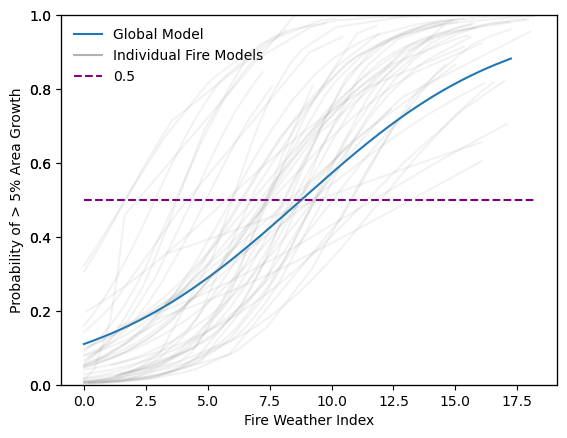

In [32]:
### Make a figure with relative growth instead of constant-unit growth

x= 'GEOS5_IMERGEARLY'
y = "spread_bool_frac_05"

fig, (ax1, ax2) = plot_logit(fire_delta = fire, fire_test = fire_test, x= 'GEOS5_IMERGEARLY', y = y)
ax1.set_ylabel("Probability of > 5% Area Growth")
ax1.set_xlabel("Fire Weather Index")
ax1.plot([None], [None], color = "grey",  alpha = 0.6, label = "Individual Fire Models")
ax1.hlines(0.5, xmin = 0, xmax =  fire_df[x].max(), color = "purple", linestyle = "dashed", label = "0.5")
ax1.legend(framealpha = 0, loc = 'upper left')


ax3 = ax2.twinx()
for fid in fire_df[~fire_df[f'{x}_thresh_{y}'].isnull()].fireID.unique():
    path = fire_df[fire_df.fireID == fid][f'path_{x}_thresh_{y}'].iloc[0]
    model = load_model(path)
    sub_df = fire_df[fire_df.fireID == fid]
    sub_df = sub_df[[x, y]].drop_duplicates()
    sub_df = sub_df[[x, y]].dropna()
    sub_df = sub_df.sort_values(by = x)
    predictions = model.get_prediction(sub_df)
    sub_df.loc[:, "fitted"] = model.fittedvalues
    sub_df.loc[:, "predicted"] =  predictions.predicted
    ax3.plot(sub_df[f'{x}'], sub_df.predicted, color = "grey",  alpha = 0.1, label = f"{fid}") # color = "grey", 
    ax3.set_ylim(0, 1)
    #ax3.yaxis.set_major_formatter(plt.NullFormatter())
    ax3.get_yaxis().set_visible(False)
    ax3.yaxis
    #ax3.hlines(0.5, color = "purple", linestyle = "dashed", label = "0.5")
#ax3.legend()
plt.savefig("some_figs/logit_model_plots/Relative_growth_Global_and_individual_logit.svg")
plt.show()



In [33]:


y_col_name = f'GEOS5_IMERGEARLY_thresh_{y}'


pct_fire_sig = len(fire_df[~fire_df[y_col_name].isna()].fireID.unique()) / len(fire_df.fireID.unique())
pct_fire_sig_total = len(fire_df[~fire_df[y_col_name].isna()].fireID.unique()) / len(fire3.fireID.unique())

print(f'Percent of fires that logit that found a significant spread threoshold for {y} {pct_fire_sig }')
print(f" N = {len(fire_df[~fire_df[y_col_name].isna()].fireID.unique())} fires, {round(pct_fire_sig, 2) * 100}% of total fires. Logit models fit against GEOS5 + IMERGE")

Percent of fires that logit that found a significant spread threoshold for spread_bool_frac_05 0.6103896103896104
 N = 47 fires, 61.0% of total fires. Logit models fit against GEOS5 + IMERGE


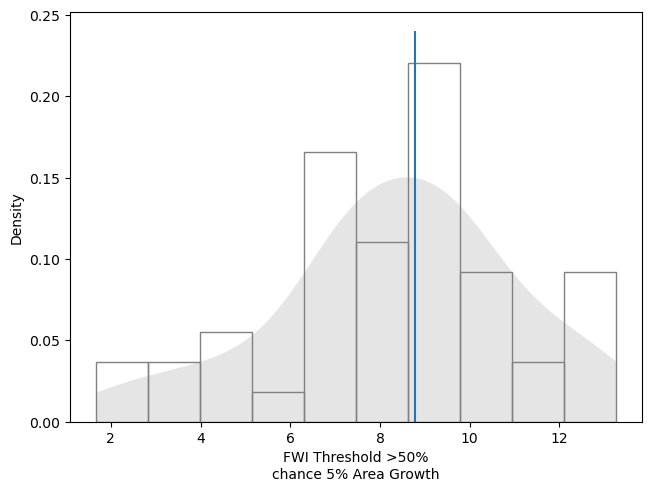

In [34]:
tot_sig_fires = len(fire_df.groupby('fireID')[y_col_name].max())


factor = 10

style = {'facecolor': 'none', 'edgecolor': 'gray'}
fig, ax = plt.subplots(layout="constrained")
ax.hist( fire_df.groupby('fireID')[y_col_name].max(), density=True, **style)
#ax.set_axis_off()
ax2.hist( fire_df.groupby('fireID')[y_col_name].max(), **style)
#ax.set_ylabel("Number of Fires")
#ax.set_xlabel(f"FWI Thresh >50% chance 1 km^2 growth")
#ax.set_title(f" N = {len(fire_df[~fire_df[y_col_name].isna()].fireID.unique())} fires, {round(pct_fire_sig, 2) * 100}% of fires with 6 days,{round(pct_fire_sig_total, 2)} of total fires. \n Logit models fit against GEOS5 + IMERGE")
sns.kdeplot(fire_df.groupby('fireID')[y_col_name].max(), fill=True, common_norm=False,  color = "gray", alpha=.2, linewidth=0, label = "Individual fires", cut = 0,  ax = ax)
#ax.yaxis.set_major_formatter(formatter)
ax.vlines(8.77760, ymin = 0, ymax = 0.24, color = "C0", label = "Global Model")
ax.set_xlabel("FWI Threshold >50%\nchance 5% Area Growth")
#ax.legend()
# plt.rcParams['axes.labelsize'] = 14 * factor # Set axes label font size
# plt.rcParams['axes.titlesize'] = 16 * factor # Set axes title font size
# plt.rcParams['xtick.labelsize'] = 10 * factor # Set x-axis tick label font size
# plt.rcParams['ytick.labelsize'] = 10  * factor# Set y-axis tick label font size
# plt.rcParams['legend.fontsize'] = 12 * factor # Set legend font size
# plt.rcParams['figure.constrained_layout.use'] = True
#plt.tight_layout()
plt.savefig("some_figs/logit_model_plots/relative_growth_Density_individual_fire_logit_model.svg",  transparent=True, bbox_inches = "tight")

plt.show()

In [35]:
# smol = fire3[fire3.fireID == '1034']

# foo = make_logit_one_fire(smol ,x='GEOS5_IMERGEARLY',  y = "spread_bool_100")
# foo

In [36]:
model

In [37]:
## Logit model with landcover as the explanatory variable: 

fire3_l = pd.read_csv(f"{os.path.abspath("landcover_merged_datasets")}/fires_merged_ESACCI-LC-L4-PFT-Map-300m-P1Y-2020-v2.0.8.csv")

fire3_l = fire3_l.drop_duplicates()
fire3_l["farea_diff_stand"] = fire3_l.groupby("fireID").farea.diff()
fire3_l["spread_bool_100"] = fire3_l.farea_diff_stand > 1
fire3_l["spread_bool_100"] = fire3_l["spread_bool_100"].astype("int")

fire3_l.loc[:, "GEOS5_IMERGEARLY"] = fire3_l['GEOS-5.IMERGEARLY']

fire_l, fire_test_l = make_two_dfs(fire3_l)

Optimization terminated successfully.
         Current function value: 0.383662
         Iterations 6


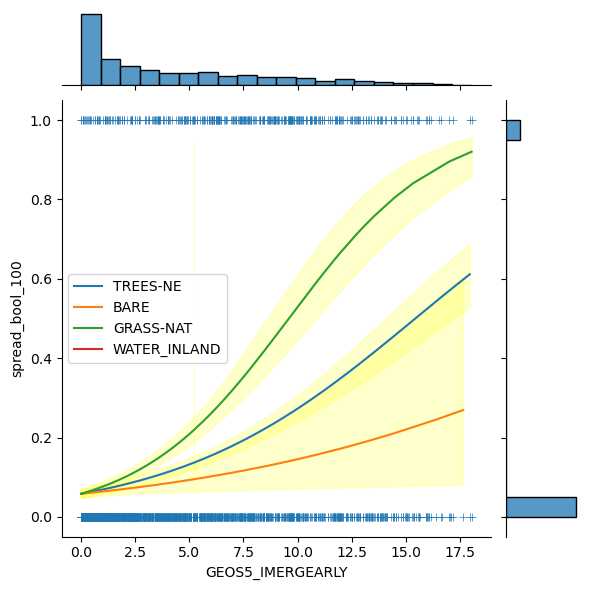

 For TREES-NE: /n ['Model_mean'] had the best accuracy (0.8419243986254296). Other scores were: 
          0                 1
0  0.841924        Model_mean
1  0.833333  most_common_null
No growth detected, no values over nan in GEOS5_IMERGEARLY
No growth detected, no values over nan in GEOS5_IMERGEARLY
 For BARE: /n ['most_common_null'] had the best accuracy (1.0). Other scores were: 
     0                 1
0  0.0        Model_mean
1  1.0  most_common_null
 For GRASS-NAT: /n ['Model_mean'] had the best accuracy (0.8539944903581267). Other scores were: 
          0                 1
0  0.853994        Model_mean
1  0.829201  most_common_null
No growth detected, no values over nan in GEOS5_IMERGEARLY
No growth detected, no values over nan in GEOS5_IMERGEARLY
Equal 0's and 1's in bool. Assuming 0. 
 For WATER_INLAND: /n ['most_common_null'] had the best accuracy (0.9333333333333333). Other scores were: 
          0                 1
0  0.000000        Model_mean
1  0.933333  most_commo

/tmp/ipykernel_2413/2161782869.py:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/tmp/ipykernel_2413/2161782869.py:62: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/tmp/ipykernel_2413/2161782869.py:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/tmp/ipykernel_2413/21

In [38]:
foo = fire3_l.groupby("fireID").field_response_type.unique().reset_index()
multi_sup_ids = foo[foo.field_response_type.apply(len) == 2].fireID.unique()
model = make_logit_cat(fire_delta = fire_l[~fire_l.fireID.isin(multi_sup_ids)], fire_test = fire_test_l[~fire_test_l.fireID.isin(multi_sup_ids)], x = "GEOS5_IMERGEARLY", y = "spread_bool_100", c = 'dominant_landcover' )

### Sampling here is weird -- need jacknife or boostrap??? Seems like I won;t be abel to break up the training an test in a way that preseaves the catagories -- potentially need to fit models to a bunch of version of training/test data and combine somehow. 

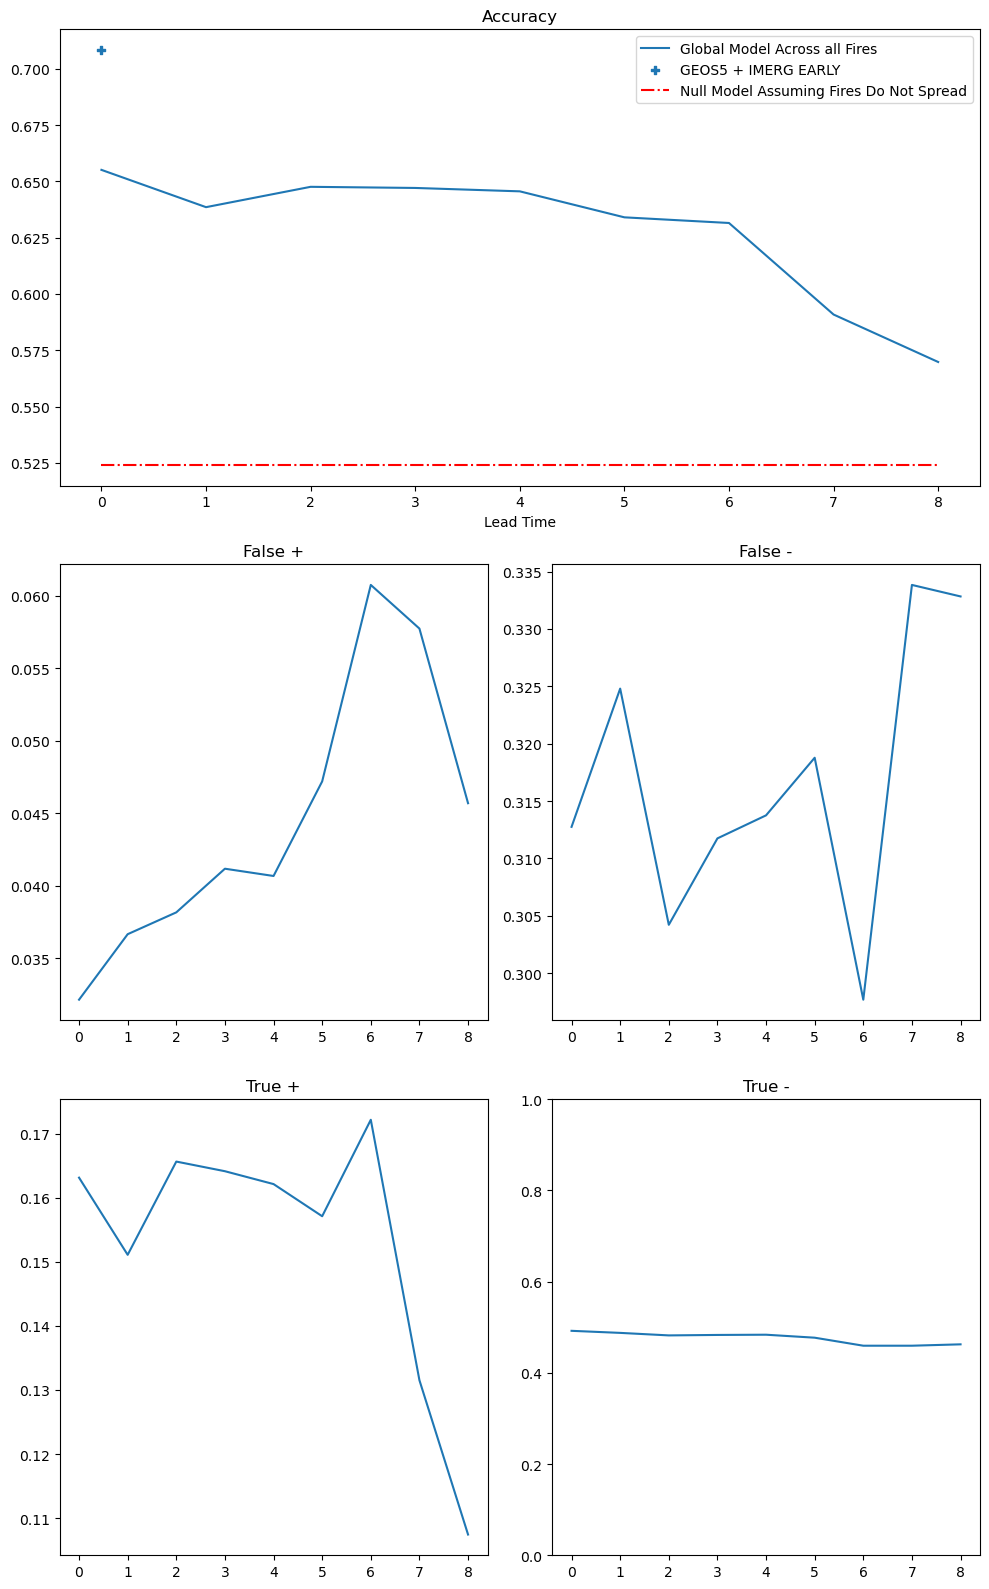

In [48]:
#### looking at if the forecast worked (using global model's threshold).
will_grow = 6.91019992068806 ### Would be better to progamatically pass this
fwi_vars = ["GEOS5_IMERGEARLY", 'FWI',
       'FWI_lead_1', 'FWI_lead_2', 'FWI_lead_3', 'FWI_lead_4', 'FWI_lead_5',
       'FWI_lead_6', 'FWI_lead_7', 'FWI_lead_8', "most_common"]
## Across all fires 
# smp_df = pd.DataFrame(columns={"false_pos": None, 
#                       "false_neg" : None, 
#                       "true_pos" : None, 
#                       "true_neg" : None,
#                       "accuracy": None})


# smp_df = pd.DataFrame(None, index=fwi_vars, columns=["false_pos", "false_neg", "true_pos", "true_neg", "accuracy"])
# for i in fwi_vars:

#     x = i
#     y = "spread_bool_100"
#     fire_tmp = fire3
#     fire_tmp.loc[:, "most_common"] = fire_tmp[y].mode().iloc[0]
#     if len(fire_tmp[y].mode()) > 1:
#         print("Equal 0's and 1's in bool. Assuming 0.")
    
#     #fire_tmp = fire_tmp[[x, y]].drop_duplicates() ## Correct?? Could this *under sample* the small fires (more likely to have same FWI?
#     #fire_tmp = fire_tmp[[x, y]].dropna()
    
    
#     false_positives = len(fire3[(fire3[x] >= will_grow) &  (fire3[y] == 0)][y])/ len(fire3[y]) ## said it would grow, but didn't
#     false_negatives = len(fire3[(fire3[x] < will_grow) &  (fire3[y] == 1)][y])/ len(fire3[y]) ## Did grow, but said it wouldn't
    
#     true_positives = len(fire3[(fire3[x] >= will_grow) &  (fire3[y] == 1)][y])/ len(fire3[y])
#     true_negatives = len(fire3[(fire3[x] < will_grow) &  (fire3[y] == 0)][y])/ len(fire3[y])
#     accuracy = (true_positives + true_negatives)
#     smp_df.loc[x, "false_pos"] = false_positives
#     smp_df.loc[x, "false_neg"] = false_negatives
#     smp_df.loc[x, "true_pos"] = true_positives
#     smp_df.loc[x, "true_neg"] = true_negatives
#     smp_df.loc[x, "accuracy"] = accuracy


smp_df = pd.DataFrame(None, index=fwi_vars, columns=["false_pos", "false_neg", "true_pos", "true_neg", "accuracy"])
for i in fwi_vars:

    x = i
    y = "spread_bool_100"
    fire_tmp = fire_test
    fire_tmp.loc[:, "most_common"] = fire_tmp[y].mode().iloc[0]
    if len(fire_tmp[y].mode()) > 1:
        print("Equal 0's and 1's in bool. Assuming 0.")
    
    #fire_tmp = fire_tmp[[x, y]].drop_duplicates() ## Correct?? Could this *under sample* the small fires (more likely to have same FWI?
    #fire_tmp = fire_tmp[[x, y]].dropna()
    
    
    false_positives = len(fire_test[(fire_test[x] >= will_grow) &  (fire_test[y] == 0)][y])/ len(fire_test[y]) ## said it would grow, but didn't
    false_negatives = len(fire_test[(fire_test[x] < will_grow) &  (fire_test[y] == 1)][y])/ len(fire_test[y]) ## Did grow, but said it wouldn't
    
    true_positives = len(fire_test[(fire_test[x] >= will_grow) &  (fire_test[y] == 1)][y])/ len(fire_test[y])
    true_negatives = len(fire_test[(fire_test[x] < will_grow) &  (fire_test[y] == 0)][y])/ len(fire_test[y])
    accuracy = (true_positives + true_negatives)
    smp_df.loc[x, "false_pos"] = false_positives
    smp_df.loc[x, "false_neg"] = false_negatives
    smp_df.loc[x, "true_pos"] = true_positives
    smp_df.loc[x, "true_neg"] = true_negatives
    smp_df.loc[x, "accuracy"] = accuracy
  
    

lead_time = [None, 0, 1,2, 3, 4, 5, 6, 7, 8, None]
smp_df.loc[:, "lead_time"] = lead_time

fig = plt.figure(figsize=(10, 16))

# Using gridspec to create custom layout
gs = fig.add_gridspec(3, 2)  # 3 rows, 2 columns grid

# One large subplot spanning the entire top row (first row, both columns)
ax_big = fig.add_subplot(gs[0, :])
ax_big.set_title('Accuracy')
# Example plot for big subplot
ax_big.plot(smp_df.lead_time, smp_df.accuracy, label = "Global Model Across all Fires")
ax_big.scatter(0, smp_df.accuracy.iloc[0], label = "GEOS5 + IMERG EARLY", marker = "P") 
ax_big.set_xlabel("Lead Time")
ax_big.hlines(smp_df.accuracy.iloc[-1], xmin = 0, xmax = 8, label = "Null Model Assuming Fires Do Not Spread", color = "red",  linestyle="-.",)
ax_big.legend()
#ax_big.set_ylim(0, 1)

# Four smaller subplots in a square arrangement in the bottom two rows
ax1 = fig.add_subplot(gs[1, 0])  # Second row, first column
ax1.set_title('False +')
ax1.plot(smp_df.lead_time, smp_df.false_pos)
#ax1.set_ylim(0, 1)

ax2 = fig.add_subplot(gs[1, 1])  # Second row, second column
ax2.set_title('False -')
ax2.plot(smp_df.lead_time, smp_df.false_neg)
#ax2.set_ylim(0, 1)

ax3 = fig.add_subplot(gs[2, 0])  # Third row, first column
ax3.set_title('True +')
ax3.plot(smp_df.lead_time, smp_df.true_pos)
#ax3.set_ylim(0, 1)

ax4 = fig.add_subplot(gs[2, 1])  # Third row, second column
ax4.set_title('True -')
ax4.plot(smp_df.lead_time, smp_df.true_neg)
ax4.set_ylim(0, 1)

plt.tight_layout()
plt.show()



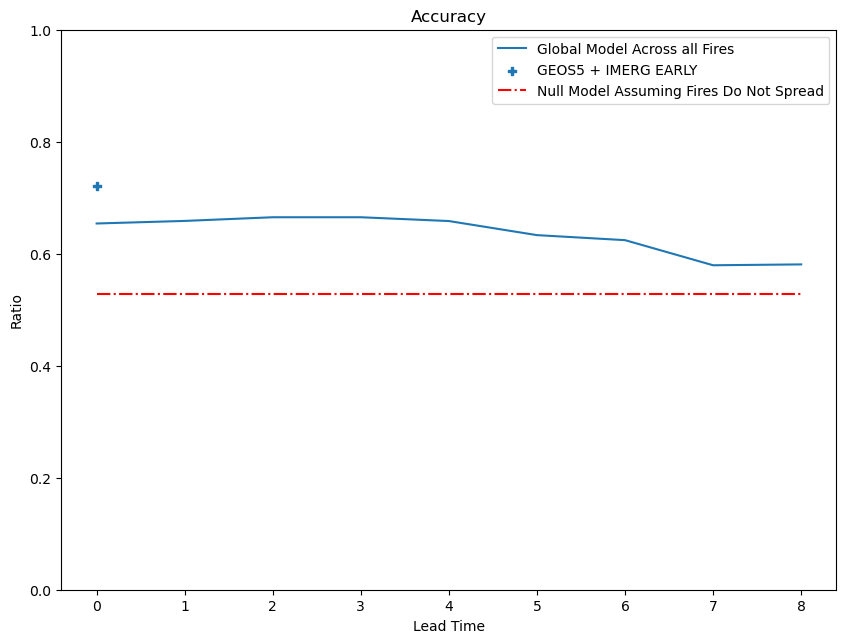

In [45]:


fig = plt.figure(figsize=(10, 16))

# Using gridspec to create custom layout
gs = fig.add_gridspec(2, 1)  # 3 rows, 2 columns grid

# One large subplot spanning the entire top row (first row, both columns)
ax_big = fig.add_subplot(gs[0, :])
ax_big.set_title('Accuracy')
# Example plot for big subplot
ax_big.plot(smp_df.lead_time, smp_df.accuracy, label = "Global Model Across all Fires")
ax_big.scatter(0, smp_df.accuracy.iloc[0], label = "GEOS5 + IMERG EARLY", marker = "P") 
ax_big.set_xlabel("Lead Time")
ax_big.set_ylabel("Ratio")
ax_big.hlines(smp_df.accuracy.iloc[-1], xmin = 0, xmax = 8, label = "Null Model Assuming Fires Do Not Spread", color = "red",  linestyle="-.",)
ax_big.legend()
ax_big.set_ylim(0, 1)



### PER FIRE DOES NOT LOOK GREAT -- to many funky jumps in shorter fires
# def per_fire_global_thresh(fire3):
#     smp_df = pd.DataFrame(None, index=fwi_vars, columns=["false_pos", "false_neg", "true_pos", "true_neg", "accuracy"])
#     for i in fwi_vars:
    
#         x = i
#         y = "spread_bool_100"
#         fire_tmp = fire3
#         fire_tmp.loc[:, "most_common"] = fire_tmp[y].mode().iloc[0]
#         if len(fire_tmp[y].mode()) > 1:
#             print("Equal 0's and 1's in bool. Assuming 0.")
        
#         #fire_tmp = fire_tmp[[x, y]].drop_duplicates() ## Correct?? Could this *under sample* the small fires (more likely to have same FWI?
#         #fire_tmp = fire_tmp[[x, y]].dropna()
        
        
#         false_positives = len(fire3[(fire3[x] >= will_grow) &  (fire3[y] == 0)][y])/ len(fire3[y]) ## said it would grow, but didn't
#         false_negatives = len(fire3[(fire3[x] < will_grow) &  (fire3[y] == 1)][y])/ len(fire3[y]) ## Did grow, but said it wouldn't
        
#         true_positives = len(fire3[(fire3[x] >= will_grow) &  (fire3[y] == 1)][y])/ len(fire3[y])
#         true_negatives = len(fire3[(fire3[x] < will_grow) &  (fire3[y] == 0)][y])/ len(fire3[y])
#         accuracy = (true_positives + true_negatives)
#         smp_df.loc[x, "false_pos"] = false_positives
#         smp_df.loc[x, "false_neg"] = false_negatives
#         smp_df.loc[x, "true_pos"] = true_positives
#         smp_df.loc[x, "true_neg"] = true_negatives
#         smp_df.loc[x, "accuracy"] = accuracy
      
        
    
#     lead_time = [None, 0, 1,2, 3, 4, 5, 6, 7, 8, None]
#     smp_df.loc[:, "lead_time"] = lead_time
#     return(smp_df)

# for i in fire3.fireID.unique():
#     f_df = per_fire_global_thresh(fire3[fire3.fireID == i])
#     ax_big.plot(f_df.lead_time, f_df.accuracy, color = "grey", alpha = 0.1)

plt.savefig("some_figs/logit_model_plots/model_accuracy_by_lead_time.png")


In [41]:
## Look at how the threshold agrees with # of fires spreading

# num_fr = pd.DataFrame({"Num_fire_spreading_1km2" :None, 
#                       "Num_fire_over_thresh": None,
#                       "t": None})

num_fr = pd.DataFrame(None, index=range(0, len(fire3.t.unique())), columns=["Num_fire_spreading_1km2", "Num_fire_over_thresh", "t", "total_fires"])
for i,t in enumerate(fire3.t.unique()):
    #print(i)
    fr_t = fire3[fire3.t == t]
    num_fr.loc[i, "t"] = t
    num_fr.loc[i, "Num_fire_spreading_1km2"] = len(fr_t[fr_t.farea_diff_stand >= 1].fireID.unique())
    num_fr.loc[i, "Num_fire_over_thresh"] = len(fr_t[fr_t.GEOS5_IMERGEARLY >= will_grow].fireID.unique())
    num_fr.loc[i, "total_fires"] = len(fr_t.fireID.unique())

num_frt = pd.DataFrame(None, index=range(0, len(fire3.t.unique())), columns=["Num_fire_spreading_1km2", "Num_fire_over_thresh", "t", "total_fires"])
for i,t in enumerate(fire_test.t.unique()):
    #print(i)
    fr_tt = fire_test[fire_test.t == t]
    num_frt.loc[i, "t"] = t
    num_frt.loc[i, "Num_fire_spreading_1km2"] = len(fr_tt[fr_tt.farea_diff_stand >= 1].fireID.unique())
    num_frt.loc[i, "Num_fire_over_thresh"] = len(fr_tt[fr_tt.GEOS5_IMERGEARLY >= will_grow].fireID.unique())
    num_frt.loc[i, "total_fires"] = len(fr_tt.fireID.unique())
    


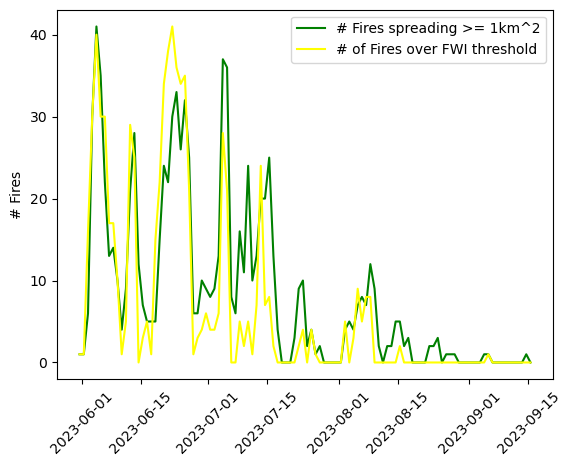

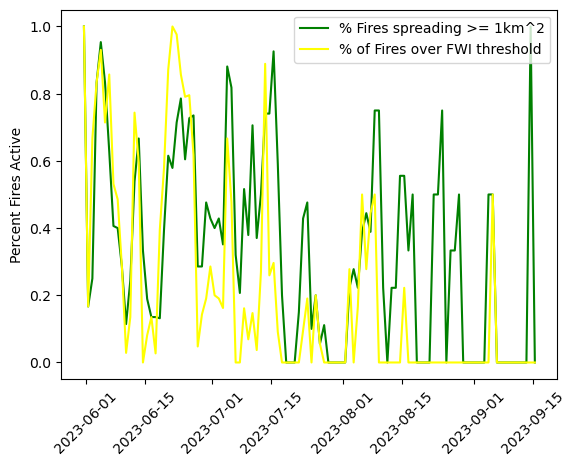

In [42]:



num_fr = num_fr.sort_values(by = "t")


fig, ax = plt.subplots()
ax.plot(num_fr.t, num_fr.Num_fire_spreading_1km2, color = "green", label = "# Fires spreading >= 1km^2")
ax.plot(num_fr.t, num_fr.Num_fire_over_thresh, color = "yellow", label = "# of Fires over FWI threshold")
ax.tick_params(axis='x', labelrotation = 45)
ax.set_ylabel("# Fires")
ax.legend()
plt.show()


fig, ax = plt.subplots()
ax.plot(num_fr.t, num_fr.Num_fire_spreading_1km2/num_fr.total_fires, color = "green", label = "% Fires spreading >= 1km^2")
ax.plot(num_fr.t, num_fr.Num_fire_over_thresh/num_fr.total_fires, color = "yellow", label = "% of Fires over FWI threshold")
ax.tick_params(axis='x', labelrotation = 45)
ax.set_ylabel("Percent Fires Active")
ax.legend()
plt.show()



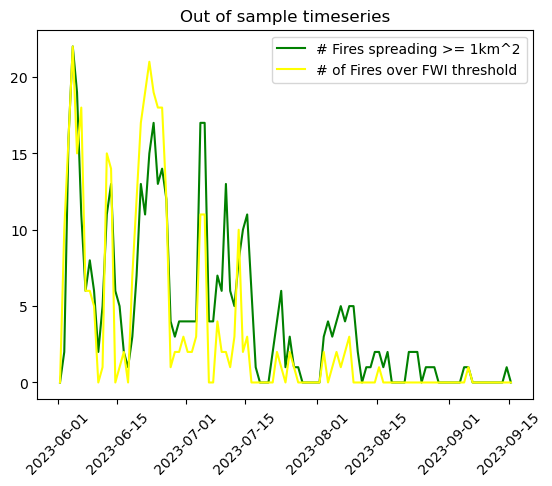

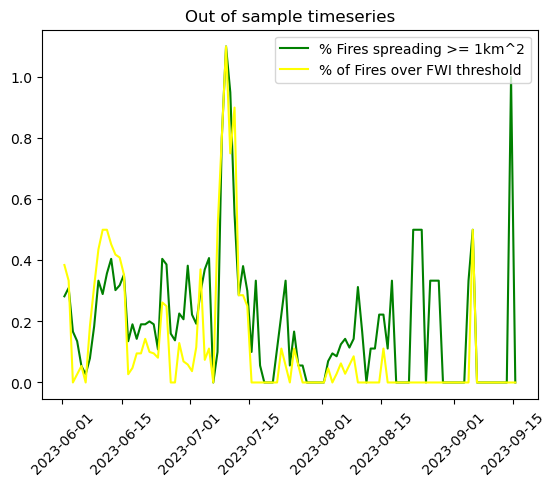

In [43]:
num_frt.t = num_frt.t.astype("datetime64[ns]")
num_frt = num_frt.sort_values(by = "t")



fig, ax = plt.subplots()
ax.set_title("Out of sample timeseries")
ax.plot(num_frt.t, num_frt.Num_fire_spreading_1km2, color = "green", label = "# Fires spreading >= 1km^2")
ax.plot(num_frt.t, num_frt.Num_fire_over_thresh, color = "yellow", label = "# of Fires over FWI threshold")
ax.tick_params(axis='x', labelrotation = 45)
ax.legend()
plt.show()


fig, ax = plt.subplots()
ax.set_title("Out of sample timeseries")
ax.plot(num_frt.t, num_frt.Num_fire_spreading_1km2/num_fr.total_fires, color = "green", label = "% Fires spreading >= 1km^2")
ax.plot(num_frt.t, num_frt.Num_fire_over_thresh/num_fr.total_fires, color = "yellow", label = "% of Fires over FWI threshold")
ax.tick_params(axis='x', labelrotation = 45)
ax.legend()
plt.show()